In [14]:
import nbformat
from nbconvert import HTMLExporter

# Leer el notebook
with open('C:\\Users\\Usuario\\Documents\\Github\\Talvi\\notebooks\\vulnerabilidad-externa-vecm v6.ipynb', 'r') as f:
    notebook = nbformat.read(f, as_version=4)

# Convertir a HTML
html_exporter = HTMLExporter()
(body, resources) = html_exporter.from_notebook_node(notebook)

# Guardar el HTML
with open('output.html', 'w') as f:
    f.write(body)

# Indicador de Vulnerabilidad Externa (IVE) — Construcción del índice

**Autores:** Manuel Alejandro Hidalgo Pérez; Ernesto Talvi  
**Proyecto:** Indicador vulnerabilidad Latinoamérica  
**Fecha:** 8 de octubre de 2025  
**Versión del cuaderno:** v0.9  
**Licencia:** © 2025 Manuel Alejandro Hidalgo Pérez y Ernesto Talvi. Todos los derechos reservados.  
<!-- Cambia esta línea si prefieres CC BY-NC 4.0 u otra licencia. -->

---

## Propósito
Este cuaderno construye el **Índice de Vulnerabilidad Externa (IVE)** a partir de un modelo de corrección de errores (ECM) con cointegración, combinando:
1) desequilibrio de largo plazo (|ECT| normalizado), y  
2) volatilidad de corto plazo (σ móvil de residuos),  
para señalizar riesgo macro a 1–2 trimestres y generar **figuras** y **CSV** reproducibles.

## Flujo (pipeline)
**Datos** → **Tests de integración/cointegración** → **ECM** → **IRFs** → **Σ<sub>t</sub> (volatilidad)** → **μ<sub>t</sub>, σ<sub>t</sub>** → **Índice IVE** → **Figuras/CSV**.

## Parámetros clave (por defecto)
- Horizonte de choque: `H = 4` trimestres  
- Ventana de volatilidad: `WINDOW_SIGMA = 40` períodos  
- Elasticidad de penalización por riesgo: `LAMBDA = 1.0`  
- Ventana COVID (exclusión opcional): `2020-03-01` a `2021-06-30`  
*(Estos valores pueden redefinirse en el bloque `CONFIG`.)*

## Cómo usar este cuaderno
1. Verifica/ajusta rutas y `CONFIG` al inicio.  
2. Ejecuta todo (Kernel → Restart & Run All).  
3. Revisa salidas en `figures/` y CSVs asociados.

## Salidas esperadas
- Gráficos: `figures/vulnerability_*.pdf` (y opcional `.png`)  
- Tablas/CSV: índice y métricas resumen para validación/backtesting

## Requisitos
Python ≥ 3.10 | `pandas`, `numpy`, `statsmodels`, `matplotlib`  
*(Si usas entornos, documenta el `requirements.txt` o `environment.yml`.)*

> **Nota:** Este IVE complementa el análisis macro-financiero; no lo sustituye. Interpretar junto con información doméstica y de estabilidad financiera.


In [15]:
# ==============================================================================
# FASE 1: CONFIGURACIÓN, CARGA Y PREPARACIÓN DE DATOS
# ==============================================================================

# --- 1. IMPORTACIÓN DE LIBRERÍAS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

# Solo silencia warnings ruidosos conocidos (sin tapar el resto)
warnings.filterwarnings(
    "ignore",
    message="Non-invertible starting MA.*"  # ejemplo statsmodels si aplica
)
warnings.filterwarnings(
    "ignore",
    message="A date index has been provided, but it has no associated frequency"
)


# --- 3. CARGA Y PROCESAMIENTO INICIAL ---

# DataFrame de Indicadores Macro (será mensual)
df_indicadores = pd.read_csv('../data/indicadores/indicadores_macroeconomicos.csv',
                             sep=';', encoding='latin1')
df_indicadores = df_indicadores.set_index('fecha')
df_indicadores.index = df_indicadores.index.astype(str)
df_indicadores.index.name = 'fecha'

# DataFrame Termotrade (mensual)
df_termotrade = pd.read_csv('../data/indicadores/monthly_results_brazil.csv',
                            sep=";", encoding='latin1')
df_termotrade = df_termotrade[['date', 'ctot_level']]
df_termotrade = df_termotrade.rename(columns={'ctot_level': 'termoftrade'})
df_termotrade = df_termotrade.set_index('date')
df_termotrade.index = pd.to_datetime(df_termotrade.index).strftime('%Y%m')
df_termotrade.index.name = 'fecha'

# DataFrame PIB de Brasil (trimestral)
gdp_brazil = pd.read_csv('../data/QGDP/brazil.csv', sep=",", encoding='latin1')
gdp_brazil = gdp_brazil.set_index(gdp_brazil.columns[0])
gdp_brazil.index = pd.to_datetime(gdp_brazil.index).strftime('%Y%m')
gdp_brazil = gdp_brazil.rename(columns={gdp_brazil.columns[0]: 'GDP_BRAZIL'})

# --- 4. CONSOLIDACIÓN DE DATOS MENSUALES ---
# Unimos los dos dataframes mensuales
df_monthly = df_indicadores.join(df_termotrade, how='outer')

# Creación de la variable dummy para la pandemia sobre los datos mensuales
df_monthly['pandemia_dummy'] = 0
start_date_dummy = '202003'
end_date_dummy = '202009'
df_monthly.loc[start_date_dummy:end_date_dummy, 'pandemia_dummy'] = 1

# --- 5. ALINEACIÓN DE FRECUENCIAS (MENSUAL A TRIMESTRAL) ---
print("="*50)
print("🔧 ALINEANDO DATOS A FRECUENCIA TRIMESTRAL")
print("="*50)

# Convertir índices a Datetime para poder remuestrear
gdp_brazil.index = pd.to_datetime(gdp_brazil.index, format='%Y%m')
df_monthly.index = pd.to_datetime(df_monthly.index, format='%Y%m')
print("✅ Índices convertidos a formato Datetime.")

# Remuestrear los datos mensuales a trimestrales
# Usamos .mean() para los indicadores continuos y .max() para la dummy
df_monthly_quarterly = df_monthly.drop(columns=['pandemia_dummy']).resample('Q').mean()
df_dummy_quarterly = df_monthly[['pandemia_dummy']].resample('Q').max()

# Unir los datos mensuales ya agregados
df_monthly_agg = df_monthly_quarterly.join(df_dummy_quarterly)
print("✅ Datos mensuales agregados a trimestres.")

# Estandarizar los índices de ambos DataFrames al inicio del trimestre
# Esto asegura una unión perfecta
gdp_brazil.index = gdp_brazil.index.to_period('Q').start_time
df_monthly_agg.index = df_monthly_agg.index.to_period('Q').start_time
print("✅ Índices estandarizados al inicio del trimestre.")

# --- 6. CREACIÓN DEL DATAFRAME FINAL ---
# Unir los datos trimestrales del PIB con los datos mensuales agregados
df_aligned = gdp_brazil.join(df_monthly_agg, how='inner')
df_aligned.dropna(inplace=True)

# Crear la versión en logaritmo del PIB
df_aligned['log_gdp_brazil'] = np.log(df_aligned['GDP_BRAZIL'])

# 2. Aplicar logaritmo a términos de intercambio (V3 no lo hacía)
df_aligned['log_tot_brazil'] = np.log(df_aligned['termoftrade'])


# 3. Crear variables financieras (faltaban en V3)
df_aligned['us_10y'] = df_aligned['DGS10']
df_aligned['risk_spread'] = df_aligned['SPREAD_USA']

# Reordenar columnas para tener las variables principales al final
main_vars = ['GDP_BRAZIL', 'log_gdp_brazil']
other_vars = [col for col in df_aligned.columns if col not in main_vars]
df_aligned = df_aligned[main_vars + other_vars]


print(f"\n📊 DATOS FINALES ALINEADOS:")
print(f"   Observaciones: {len(df_aligned)}")
if not df_aligned.empty:
    print(f"   Período: {df_aligned.index.min().strftime('%Y-%m-%d')} a {df_aligned.index.max().strftime('%Y-%m-%d')}")
    print(f"   Columnas: {list(df_aligned.columns)}")
else:
    print("⚠️ ADVERTENCIA: El DataFrame está vacío. Revisa los rangos de fechas.")

print("\n primeiras 5 observações do dataset final:")
display(df_aligned.head())

🔧 ALINEANDO DATOS A FRECUENCIA TRIMESTRAL
✅ Índices convertidos a formato Datetime.
✅ Datos mensuales agregados a trimestres.
✅ Índices estandarizados al inicio del trimestre.

📊 DATOS FINALES ALINEADOS:
   Observaciones: 100
   Período: 2000-01-01 a 2024-10-01
   Columnas: ['GDP_BRAZIL', 'log_gdp_brazil', 'PI_USA', 'PI_FRA', 'PI_GER', 'PI_ITA', 'PI_UK', 'DGS10', 'SPREAD_USA', 'termoftrade', 'pandemia_dummy', 'log_tot_brazil', 'us_10y', 'risk_spread']

 primeiras 5 observações do dataset final:


,GDP_BRAZIL,log_gdp_brazil,PI_USA,PI_FRA,PI_GER,PI_ITA,PI_UK,DGS10,SPREAD_USA,termoftrade,pandemia_dummy,log_tot_brazil,us_10y,risk_spread
2000-01-01,192382.2,12.167239,91.738900,109.200000,83.066667,119.500000,76.533333,6.479007,5.018454,99.923617,0,4.604406,6.479007,5.018454
2000-04-01,194948.4,12.180490,92.867467,110.933333,85.300000,121.700000,77.433333,6.176085,5.960372,99.878941,0,4.603959,6.176085,5.960372
2000-07-01,197616.2,12.194082,92.803667,111.100000,86.766667,121.633333,78.133333,5.893029,6.312758,99.783583,0,4.603004,5.893029,6.312758
2000-10-01,199860.6,12.205375,92.548700,112.500000,87.100000,123.966667,79.700000,5.565405,8.132197,99.716377,0,4.602330,5.565405,8.132197
2001-01-01,200333.4,12.207738,91.411467,113.166667,87.500000,121.766667,80.400000,5.048451,8.006848,99.756359,0,4.602731,5.048451,8.006848


# Creo indicador industrial endógeno buscando pesos que maximice la correlación con GDP

📊 Matriz de correlaciones (tasas de crecimiento logarítmicas):


,d_PI_USA,d_PI_FRA,d_PI_GER,d_PI_ITA,d_PI_UK,d_log_gdp_brazil
d_PI_USA,1.000000,0.883625,0.876022,0.845928,0.769587,0.776292
d_PI_FRA,0.883625,1.000000,0.881475,0.925222,0.848340,0.800802
d_PI_GER,0.876022,0.881475,1.000000,0.837460,0.783795,0.784916
d_PI_ITA,0.845928,0.925222,0.837460,1.000000,0.802446,0.732792
d_PI_UK,0.769587,0.848340,0.783795,0.802446,1.000000,0.708053
d_log_gdp_brazil,0.776292,0.800802,0.784916,0.732792,0.708053,1.000000


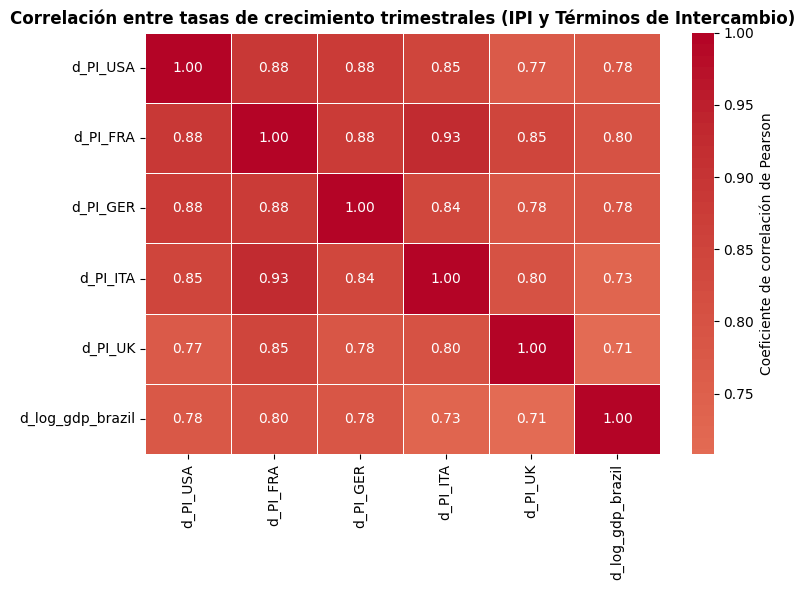

🔹 Correlación de crecimiento de log_gdp_brazil con cada IPI:


d_PI_FRA    0.800802
d_PI_GER    0.784916
d_PI_USA    0.776292
d_PI_ITA    0.732792
d_PI_UK     0.708053
Name: d_log_gdp_brazil, dtype: float64

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Seleccionar variables relevantes ---
vars_pi = ['PI_USA', 'PI_FRA', 'PI_GER', 'PI_ITA', 'PI_UK', 'log_gdp_brazil']

# Subconjunto del dataframe
df_growth = df_aligned[vars_pi].copy()

# --- 2. Calcular tasas de crecimiento trimestrales ---
# Usamos log-diferencias: Δln(x) ≈ tasa de crecimiento porcentual
for col in df_growth.columns:
    df_growth[f'd_{col}'] = df_growth[col].apply(np.log).diff()

# Mantener solo las columnas transformadas
growth_cols = [f'd_{col}' for col in vars_pi]
df_growth = df_growth[growth_cols].dropna()

# --- 3. Calcular correlación ---
corr_matrix_growth = df_growth.corr()

print("📊 Matriz de correlaciones (tasas de crecimiento logarítmicas):")
display(corr_matrix_growth)

# --- 4. Visualización con mapa de calor ---
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_growth, annot=True, cmap='coolwarm', center=0, fmt=".2f",
            linewidths=0.5, cbar_kws={'label': 'Coeficiente de correlación de Pearson'})
plt.title('Correlación entre tasas de crecimiento trimestrales (IPI y Términos de Intercambio)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 5. Correlación individual con log_gdp_brazil ---
corr_with_tot = corr_matrix_growth['d_log_gdp_brazil'].drop('d_log_gdp_brazil').sort_values(ascending=False)
print("🔹 Correlación de crecimiento de log_gdp_brazil con cada IPI:")
display(corr_with_tot)



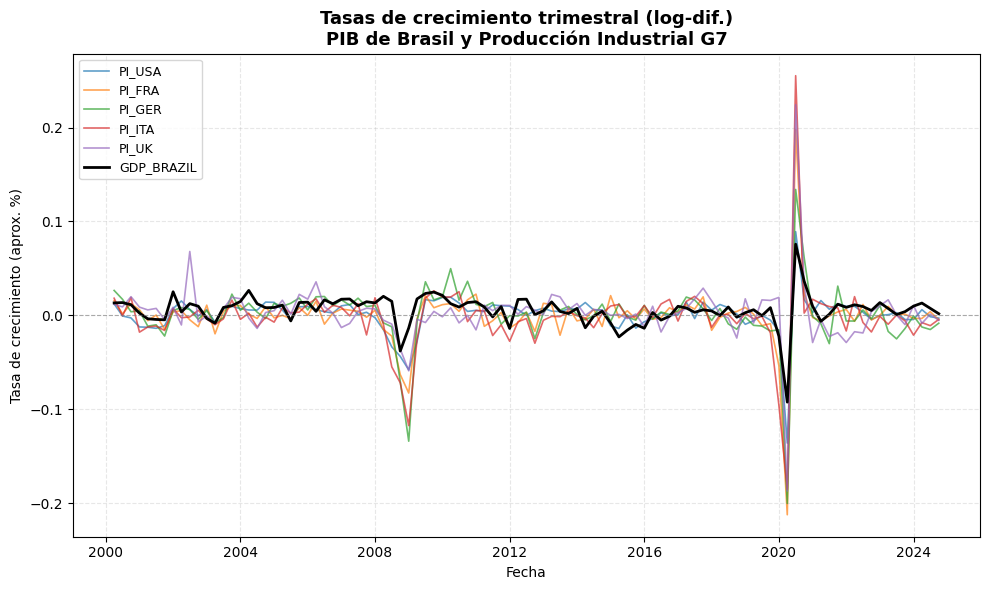

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Seleccionar variables relevantes ---
vars_pi = ['PI_USA', 'PI_FRA', 'PI_GER', 'PI_ITA', 'PI_UK']
var_gdp = 'GDP_BRAZIL'

# --- 2. Calcular tasas de crecimiento logarítmicas ---
df_growth = df_aligned[vars_pi + [var_gdp]].copy()
df_growth = np.log(df_growth).diff().dropna()

# --- 3. Crear el gráfico ---
plt.figure(figsize=(10, 6))

# Graficar cada IPI con líneas finas y colores suaves
for col in vars_pi:
    plt.plot(df_growth.index, df_growth[col], label=col, alpha=0.7, linewidth=1.2)

# Destacar el crecimiento del PIB de Brasil con línea más gruesa
plt.plot(df_growth.index, df_growth[var_gdp], color='black', linewidth=2.0, label='GDP_BRAZIL')

# --- 4. Personalización del gráfico ---
plt.title('Tasas de crecimiento trimestral (log-dif.)\nPIB de Brasil y Producción Industrial G7', fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Tasa de crecimiento (aprox. %)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()


📊 Pesos óptimos para maximizar la correlación con el crecimiento del PIB de Brasil:


,País,Peso óptimo
0,PI_USA,0.315
1,PI_FRA,0.360
2,PI_GER,0.270
3,PI_ITA,0.000
4,PI_UK,0.055


🔹 Correlación máxima alcanzada: 0.823


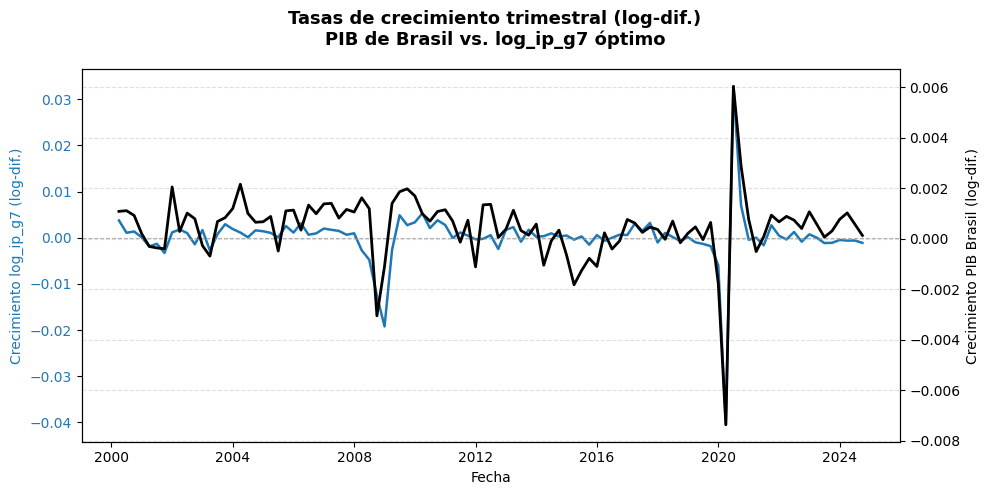

📈 Correlación entre crecimiento del IP_G7 óptimo y PIB de Brasil: 0.822


In [18]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- 1. Variables relevantes ---
vars_pi = ['PI_USA', 'PI_FRA', 'PI_GER', 'PI_ITA', 'PI_UK']
var_gdp = 'log_gdp_brazil'

# Subconjunto del DataFrame
df_corr = df_aligned[vars_pi + [var_gdp]].dropna()

# --- 2. Calcular tasas de crecimiento (log-diferencias) ---
df_growth = np.log(df_corr).diff().dropna()

# --- 3. Función objetivo: maximizar correlación ---
def objective(weights):
    ip_g7_weighted = np.dot(df_growth[vars_pi].values, weights)
    corr = np.corrcoef(ip_g7_weighted, df_growth[var_gdp].values)[0, 1]
    return -corr  # negativo porque minimize minimiza

# --- 4. Restricciones ---
cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * len(vars_pi)
w0 = np.ones(len(vars_pi)) / len(vars_pi)

# --- 5. Optimización ---
result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=cons)
opt_weights = result.x
opt_corr = -result.fun

# --- 6. Resultados ---
weights_table = pd.DataFrame({'País': vars_pi, 'Peso óptimo': opt_weights})
print("📊 Pesos óptimos para maximizar la correlación con el crecimiento del PIB de Brasil:")
display(weights_table.style.format({'Peso óptimo': '{:.3f}'}))
print(f"🔹 Correlación máxima alcanzada: {opt_corr:.3f}")

# --- 7. Crear el índice ponderado y calcular tasas de crecimiento ---
df_aligned['log_ip_g7'] = np.log(np.dot(df_aligned[vars_pi], opt_weights))
df_plot = np.log(df_aligned[['log_ip_g7', var_gdp]]).diff().dropna()

# --- 8. Visualización con doble eje Y ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje izquierdo → log_ip_g7
ax1.plot(df_plot.index, df_plot['log_ip_g7'], color='tab:blue', linewidth=1.8, label='Crecimiento log_ip_g7')
ax1.set_ylabel('Crecimiento log_ip_g7 (log-dif.)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Eje derecho → PIB Brasil
ax2 = ax1.twinx()
ax2.plot(df_plot.index, df_plot[var_gdp], color='black', linewidth=2.0, label='Crecimiento PIB Brasil (log-dif.)')
ax2.set_ylabel('Crecimiento PIB Brasil (log-dif.)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Títulos y formato
fig.suptitle('Tasas de crecimiento trimestral (log-dif.)\nPIB de Brasil vs. log_ip_g7 óptimo', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# --- 9. Calcular correlación final ---
corr_final = df_plot.corr().iloc[0, 1]
print(f"📈 Correlación entre crecimiento del IP_G7 óptimo y PIB de Brasil: {corr_final:.3f}")



## FASE 2 · Diagnóstico temporal: ADF, KPSS y Johansen

**Objetivo.** Clasificar cada serie como **I(0)** o **I(1)** y, si hay ≥2 variables I(1), estimar el **rango de cointegración** con Johansen para justificar el uso de un ECM/VECM.

**Qué hace esta celda.**
1) Ejecuta **ADF** (H₀: raíz unitaria) y **KPSS** (H₀: estacionaria) sobre cada variable clave.  
2) Aplica una **regla de decisión**: se etiqueta **I(1)** si `p_ADF > 0.05` **y** `p_KPSS < 0.05`.  
   *Si KPSS devuelve `InterpolationWarning` o falla (series muy persistentes), se confía en ADF para decidir.*  
3) Construye la lista `i1_variables` y corre **Johansen (traza)** con `det_order=1` y `k_ar_diff=2`.  
4) Reporta el número de **relaciones de cointegración** `r`.

**Salidas esperadas.**
- Tabla `summary_table` con p-valores ADF/KPSS y conclusión I(0)/I(1).  
- Lista `i1_variables`.  
- Tabla/print del **test de la traza** (estadístico vs. valor crítico 5%) y veredicto `r`.

**Interpretación rápida (con tus resultados actuales).**
- I(1): `log_gdp_brazil`, `log_tot_brazil`, `us_10y`.  
- Johansen (traza) ⇒ **r = 1**. Procede ECM con un vector de cointegración.

**Precauciones.**
- Asegura frecuencia/fechas alineadas (`df_aligned`).  
- Los **warnings KPSS** indican p-valores límite (menores que la tabla); no invalidan el diagnóstico si ADF y KPSS son consistentes.

**Próximo paso.** Usar `r=1` para construir el **ECT** e ir a la estimación del **ECM** (Fase 3).


In [19]:
# ==============================================================================
# FASE 2: DIAGNÓSTICO DE PROPIEDADES TEMPORALES
# ==============================================================================

# --- 1. IMPORTACIÓN DE LIBRERÍAS PARA DIAGNÓSTICO ---
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import pandas as pd

# --- 2. FUNCIONES DE AYUDA PARA LOS TESTS ---

def test_unit_root_summary(series, name):
    """
    Ejecuta una batería de tests de raíz unitaria (ADF y KPSS) y devuelve
    un resumen y una conclusión sobre el orden de integración.
    """
    results = {'Variable': name}
    
    # Test ADF (H0: Hay raíz unitaria / No estacionaria)
    adf_test = adfuller(series.dropna(), regression='c', autolag='AIC')
    results['ADF_p_value'] = adf_test[1]
    
    # Test KPSS (H0: Es estacionaria)
    # Nota: Invertimos la lógica del p-valor para el resultado
    try:
        kpss_test = kpss(series.dropna(), regression='c', nlags='auto')
        results['KPSS_p_value'] = kpss_test[1]
    except Exception as e:
        results['KPSS_p_value'] = None # Puede fallar si la serie es muy persistente
        
    # Conclusión basada en la combinación de tests
    # Consideramos I(1) si ADF no rechaza H0 Y KPSS rechaza H0
    is_i1 = False
    if results['ADF_p_value'] > 0.05:
        if results['KPSS_p_value'] is not None and results['KPSS_p_value'] < 0.05:
            is_i1 = True
        elif results['KPSS_p_value'] is None: # Si KPSS falla, confiamos en ADF
            is_i1 = True
            
    results['Conclusion'] = 'I(1)' if is_i1 else 'I(0)'
    
    return results

# --- 3. EJECUCIÓN DE TESTS DE RAÍZ UNITARIA ---
print("="*60)
print("📊 1. ANÁLISIS DE RAÍZ UNITARIA (ESTACIONARIEDAD)")
print("="*60)

# ✅ Variables según metodología V2 (5 variables principales)
variables_to_test = ['log_gdp_brazil', 'log_ip_g7', 'log_tot_brazil', 'us_10y', 'risk_spread']


all_stationarity_results = []
for var in variables_to_test:
    if var in df_aligned.columns:
        result = test_unit_root_summary(df_aligned[var], var)
        all_stationarity_results.append(result)

# Mostrar resultados en una tabla
summary_table = pd.DataFrame(all_stationarity_results).set_index('Variable')
print(summary_table)

# Identificar variables I(1) para el siguiente paso
i1_variables = summary_table[summary_table['Conclusion'] == 'I(1)'].index.tolist()
print(f"\n✅ Variables identificadas como I(1) para cointegración: {i1_variables}")


# --- 4. TEST DE COINTEGRACIÓN DE JOHANSEN ---
print("\n" + "="*60)
print("🔗 2. TEST DE COINTEGRACIÓN DE JOHANSEN (SOBRE VARIABLES I(1))")
print("="*60)

if len(i1_variables) >= 2:
    data_johansen = df_aligned[i1_variables].dropna()
    
    # det_order=1 asume una tendencia lineal en los datos, que es común
    # k_ar_diff=2 significa que el modelo subyacente tiene 3 lags (p=k+1)
    johansen_result = coint_johansen(data_johansen.values, det_order=1, k_ar_diff=2)
    
    print(f"Variables incluidas en el test: {i1_variables}")
    
    # Interpretar el test de la traza
    print("\nResultados del Test de la Traza:")
    print("--------------------------------------------------")
    print(" H0: r=i | Estadístico | Valor Crítico 5% | Conclusión")
    print("--------------------------------------------------")
    
    num_relations = 0
    for i in range(len(i1_variables)):
        trace_stat = johansen_result.lr1[i]
        crit_val = johansen_result.cvt[i, 1]
        conclusion = "Rechaza H0" if trace_stat > crit_val else "No Rechaza H0"
        print(f" r<={i}   | {trace_stat:>11.3f} | {crit_val:>16.3f} | {conclusion}")
        if trace_stat > crit_val:
            num_relations = i + 1
            
    print("--------------------------------------------------")
    print(f"\n✅ Veredicto: Se encontraron {num_relations} relación(es) de cointegración.")
    
else:
    print("⚠️ No se encontraron suficientes variables I(1) para realizar el test de cointegración.")

📊 1. ANÁLISIS DE RAÍZ UNITARIA (ESTACIONARIEDAD)
                ADF_p_value  KPSS_p_value Conclusion
Variable                                            
log_gdp_brazil     0.463526      0.010000       I(1)
log_ip_g7          0.006177      0.100000       I(0)
log_tot_brazil     0.145009      0.034206       I(1)
us_10y             0.152874      0.010000       I(1)
risk_spread        0.004912      0.077011       I(0)

✅ Variables identificadas como I(1) para cointegración: ['log_gdp_brazil', 'log_tot_brazil', 'us_10y']

🔗 2. TEST DE COINTEGRACIÓN DE JOHANSEN (SOBRE VARIABLES I(1))
Variables incluidas en el test: ['log_gdp_brazil', 'log_tot_brazil', 'us_10y']

Resultados del Test de la Traza:
--------------------------------------------------
 H0: r=i | Estadístico | Valor Crítico 5% | Conclusión
--------------------------------------------------
 r<=0   |      38.450 |           35.012 | Rechaza H0
 r<=1   |      12.084 |           18.398 | No Rechaza H0
 r<=2   |       1.146 |         

C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3170422310.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3170422310.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3170422310.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), regression='c', nlags='auto')


## FASE 3 · Estimación del ECM con control COVID, robustez y selección final

**Objetivo.** Estimar la dinámica de corto plazo coherente con la relación de largo plazo (ECT) e identificar la especificación **final** que usaremos para construir el índice.

**Qué hace esta celda.**
1) **Controles COVID**  
   Crea `covid_crash` (2020Q1–Q2) y `covid_recovery` (2020Q3–2021Q2) como dummies exógenas para absorber outliers de la pandemia.
2) **Relación de largo plazo (cointegración)**  
   Estima por OLS:  
   \[
   \log PIB_t = \beta_0 + \beta_{ToT}\,\log ToT_t + \beta_{US10Y}\,US10Y_t + u_t
   \]  
   Define **ECT** como el residuo de esta ecuación.
3) **Búsqueda de especificación (Modelo 1: con dummies COVID)**  
   ECM sobre \(\Delta \log PIB\) con: lags del **ECT** (1…`max_ect_lags`), lags de \(\Delta\) de I(1) (`log_tot_brazil`, `us_10y`), niveles de I(0) (`log_ip_g7`, `risk_spread`) y dummies COVID.  
   Criterios de filtrado: **ECT(t-1) < 0** y **p < 0.10** (estabilidad). Selección por **AIC** (covarianza **HAC**, `maxlags=4`).
4) **Robustez (Modelo 2: excluyendo todo el período COVID)**  
   Reestima cointegración sin 2020-01…2021-06, genera `ECT_clean` y repite búsqueda (sin dummies) sobre muestra limpia.
5) **Comparación y selección**  
   Compara R² ajustado, AIC, nobs y \(\alpha\) (coef. de ECT) vs. un “modelo original” de referencia.  
   Selección final: usa **Modelo 1** si mejora R² > 5 pp y ECT estable/significativo; si el Modelo 2 no se estima, se elige Modelo 1 por defecto.
6) **Salida estructurada**  
   Guarda `final_model_results` con: modelo seleccionado, ECT(s), especificación, resultados de búsqueda y ecuación de cointegración.

**Parámetros y supuestos.**
- Rango de búsqueda: `max_ect_lags = 3`, `max_var_lags = 3`.  
- Errores **HAC** (`maxlags=4`).  
- Dummies COVID: `crash` = 2020Q1–Q2; `recovery` = 2020Q3–2021Q2.

**Interpretación rápida (con tus resultados).**
- Cointegración (muestra completa):  
  \(\beta_{ToT}\approx 8.67\) (elasticidad LR positiva), \(\beta_{US10Y}\approx -0.068\) (efecto LR negativo).  
- **Modelo final**: con dummies COVID, \(R^2_{adj}\approx 0.3895\), \(\alpha=\)ECT(t-1)\(\approx -0.0319\) (p≈0.069) ⇒ ajuste hacia el equilibrio.
- Mejora vs. base: **+21.8 pp** en R² ajustado.

**Precauciones.**
- Las dummies COVID capturan nivel/ruido de corto plazo; no sustituyen cambios estructurales de largo plazo.  
- Si el Modelo 2 no converge/queda vacío, no es evidencia contra la robustez; puede ser **tamaño muestral** insuficiente tras excluir COVID.

**Próximo paso.** Usar el **modelo final** para computar IRFs, volatilidad \(\Sigma_t\) y, finalmente, el **índice**.


In [20]:
# ==============================================================================
# FASE 3: ESTIMACIÓN DEL MODELO VECM ÓPTIMO (CON TRATAMIENTO COVID)
# ==============================================================================

from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
import numpy as np
import pandas as pd

print("="*80)
print("🎯 FASE 3: ESTIMACIÓN DEL MODELO VECM ÓPTIMO")
print("🦠 ESTRATEGIA: Control de Efectos COVID-19")
print("="*80)

# ==============================================================================
# 3.0: PREPARACIÓN - Crear Dummies COVID
# ==============================================================================

print("\n📊 PASO 0: Preparación de Variables de Control COVID")
print("-"*60)

# Crear dummies para dos fases del COVID
df_aligned['covid_crash'] = 0
df_aligned['covid_recovery'] = 0

# Fase 1: Caída abrupta (2020Q1-Q2)
crash_start = '2020-01'
crash_end = '2020-06'
df_aligned.loc[crash_start:crash_end, 'covid_crash'] = 1

# Fase 2: Recuperación distorsionada (2020Q3-2021Q2)
recovery_start = '2020-07'
recovery_end = '2021-06'
df_aligned.loc[recovery_start:recovery_end, 'covid_recovery'] = 1

n_crash = df_aligned['covid_crash'].sum()
n_recovery = df_aligned['covid_recovery'].sum()
n_total_covid = n_crash + n_recovery

print(f"✅ Dummies COVID creadas:")
print(f"   • covid_crash (2020Q1-Q2): {n_crash} observaciones")
print(f"   • covid_recovery (2020Q3-2021Q2): {n_recovery} observaciones")
print(f"   • Total período COVID: {n_total_covid} observaciones ({n_total_covid/len(df_aligned)*100:.1f}%)")

# ==============================================================================
# 3.1: RELACIÓN DE LARGO PLAZO (Sin cambios)
# ==============================================================================

print("\n📊 PASO 1: Relación de Equilibrio de Largo Plazo")
print("-"*60)

dependent_var = 'log_gdp_brazil'
coint_vars_i1 = ['log_tot_brazil', 'us_10y']

y_coint = df_aligned[dependent_var]
X_coint = df_aligned[coint_vars_i1]
X_coint_const = sm.add_constant(X_coint)

modelo_coint = OLS(y_coint, X_coint_const).fit()
ect = modelo_coint.resid
ect.name = 'ECT'

print(f"✅ Relación de cointegración estimada (toda la muestra):")
print(f"   log_gdp = {modelo_coint.params['const']:.4f} + "
      f"{modelo_coint.params['log_tot_brazil']:.4f}*log_tot + "
      f"{modelo_coint.params['us_10y']:.4f}*us_10y")

# ==============================================================================
# 3.2: MODELO 1 - Con Controles COVID (Dummy Saturación)
# ==============================================================================

print("\n" + "="*60)
print("🔍 MODELO 1: Búsqueda Óptima CON Controles COVID")
print("="*60)

def find_optimal_with_covid_controls(df_aligned, ect, max_ect_lags=3, max_var_lags=3):
    """
    Búsqueda óptima INCLUYENDO dummies COVID como controles
    """
    
    variables_i0 = ['log_ip_g7', 'risk_spread']
    coint_vars_i1 = ['log_tot_brazil', 'us_10y']
    covid_controls = ['covid_crash', 'covid_recovery']
    
    df_diff = df_aligned.diff().dropna()
    y_ecm = df_diff['log_gdp_brazil']
    
    results = []
    
    for ect_lags in range(1, max_ect_lags + 1):
        for var_lags in range(0, max_var_lags + 1):
            
            try:
                X_list = []
                
                # ECT lags
                for lag in range(1, ect_lags + 1):
                    X_list.append(ect.shift(lag).rename(f'ECT_L{lag}'))
                
                # Variables I(1) diferenciadas
                for var in coint_vars_i1:
                    X_list.append(df_diff[var].rename(f'D_{var}_L0'))
                    for lag in range(1, var_lags + 1):
                        X_list.append(df_diff[var].shift(lag).rename(f'D_{var}_L{lag}'))
                
                # Variables I(0) en niveles
                for var in variables_i0:
                    X_list.append(df_aligned[var].rename(f'{var}_L0'))
                    for lag in range(1, var_lags + 1):
                        X_list.append(df_aligned[var].shift(lag).rename(f'{var}_L{lag}'))
                
                # ✅ AÑADIR: Controles COVID
                for covid_var in covid_controls:
                    X_list.append(df_aligned[covid_var])
                
                X = pd.concat(X_list, axis=1).dropna()
                y_aligned = y_ecm.loc[X.index]
                X_with_const = sm.add_constant(X)
                
                model = OLS(y_aligned, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
                
                ect_coef_l1 = model.params.get('ECT_L1', 0)
                ect_pval_l1 = model.pvalues.get('ECT_L1', 1)
                is_stable = (ect_coef_l1 < 0) and (ect_pval_l1 < 0.10)
                
                results.append({
                    'ect_lags': ect_lags,
                    'var_lags': var_lags,
                    'aic': model.aic,
                    'bic': model.bic,
                    'r2_adj': model.rsquared_adj,
                    'nobs': model.nobs,
                    'ect_l1_coef': ect_coef_l1,
                    'ect_l1_pval': ect_pval_l1,
                    'is_stable': is_stable,
                    'model': model
                })
                
            except:
                continue
    
    results_df = pd.DataFrame(results)
    stable_models = results_df[results_df['is_stable'] == True].copy()
    
    print(f"📊 Resultados (CON controles COVID):")
    print(f"   • Especificaciones evaluadas: {len(results_df)}")
    print(f"   • Especificaciones ESTABLES: {len(stable_models)}")
    
    if len(stable_models) > 0:
        optimal = stable_models.nsmallest(1, 'aic').iloc[0]
        print(f"\n🏆 MODELO ÓPTIMO:")
        print(f"   • ECT lags: {int(optimal['ect_lags'])}")
        print(f"   • Variable lags: {int(optimal['var_lags'])}")
        print(f"   • AIC: {optimal['aic']:.3f}")
        print(f"   • R² Ajustado: {optimal['r2_adj']:.4f}")
        print(f"   • ECT(t-1): {optimal['ect_l1_coef']:.4f} (p={optimal['ect_l1_pval']:.4f})")
        
        top3 = stable_models.nsmallest(3, 'aic')[['ect_lags', 'var_lags', 'aic', 'r2_adj', 'ect_l1_coef']]
        print(f"\n📋 Top 3 Modelos:")
        print(top3.to_string(index=False))
    else:
        optimal = results_df.nsmallest(1, 'aic').iloc[0]
        print(f"\n⚠️ No se encontraron modelos estables, usando mejor por AIC")
    
    return {'optimal': optimal, 'all_results': results_df, 'stable_models': stable_models}

# Ejecutar búsqueda
spec_with_covid = find_optimal_with_covid_controls(df_aligned, ect)

# ==============================================================================
# 3.3: MODELO 2 - Sin Período COVID (Análisis de Robustez)
# ==============================================================================

print("\n" + "="*60)
print("🔬 MODELO 2: Análisis de Robustez (Sin Período COVID)")
print("="*60)

# Crear máscara para excluir TODO el período COVID
covid_mask = (df_aligned.index >= '2020-01') & (df_aligned.index <= '2021-06')
n_excluidas = covid_mask.sum()

print(f"📊 Muestra de robustez:")
print(f"   • Observaciones originales: {len(df_aligned)}")
print(f"   • Observaciones excluidas (COVID): {n_excluidas}")
print(f"   • Observaciones para estimación: {(~covid_mask).sum()}")

# Estimar relación de cointegración SIN COVID
y_coint_clean = df_aligned.loc[~covid_mask, dependent_var]
X_coint_clean = df_aligned.loc[~covid_mask, coint_vars_i1]
X_coint_clean_const = sm.add_constant(X_coint_clean)

modelo_coint_clean = OLS(y_coint_clean, X_coint_clean_const).fit()

print(f"\n✅ Relación de cointegración (sin COVID):")
print(f"   log_gdp = {modelo_coint_clean.params['const']:.4f} + "
      f"{modelo_coint_clean.params['log_tot_brazil']:.4f}*log_tot + "
      f"{modelo_coint_clean.params['us_10y']:.4f}*us_10y")

# Calcular ECT para TODA la muestra usando coeficientes limpios
ect_clean = y_coint - modelo_coint_clean.predict(X_coint_const)
ect_clean.name = 'ECT_clean'

# Buscar especificación óptima SIN COVID (sin dummies, muestra reducida)
def find_optimal_without_covid(df_aligned, ect, covid_mask, max_ect_lags=3, max_var_lags=3):
    """
    Búsqueda en muestra SIN período COVID
    """
    
    variables_i0 = ['log_ip_g7', 'risk_spread']
    coint_vars_i1 = ['log_tot_brazil', 'us_10y']
    
    df_diff = df_aligned.diff().dropna()
    y_ecm = df_diff['log_gdp_brazil']
    
    # Aplicar máscara COVID
    clean_mask = ~covid_mask
    
    results = []
    
    for ect_lags in range(1, max_ect_lags + 1):
        for var_lags in range(0, max_var_lags + 1):
            
            try:
                X_list = []
                
                for lag in range(1, ect_lags + 1):
                    X_list.append(ect.shift(lag).rename(f'ECT_L{lag}'))
                
                for var in coint_vars_i1:
                    X_list.append(df_diff[var].rename(f'D_{var}_L0'))
                    for lag in range(1, var_lags + 1):
                        X_list.append(df_diff[var].shift(lag).rename(f'D_{var}_L{lag}'))
                
                for var in variables_i0:
                    X_list.append(df_aligned[var].rename(f'{var}_L0'))
                    for lag in range(1, var_lags + 1):
                        X_list.append(df_aligned[var].shift(lag).rename(f'{var}_L{lag}'))
                
                X = pd.concat(X_list, axis=1).dropna()
                
                # ✅ FILTRAR: Solo observaciones fuera de COVID
                X_clean = X.loc[clean_mask[X.index]]
                y_clean = y_ecm.loc[X_clean.index]
                
                X_with_const = sm.add_constant(X_clean)
                model = OLS(y_clean, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
                
                ect_coef_l1 = model.params.get('ECT_L1', 0)
                ect_pval_l1 = model.pvalues.get('ECT_L1', 1)
                is_stable = (ect_coef_l1 < 0) and (ect_pval_l1 < 0.10)
                
                results.append({
                    'ect_lags': ect_lags,
                    'var_lags': var_lags,
                    'aic': model.aic,
                    'bic': model.bic,
                    'r2_adj': model.rsquared_adj,
                    'nobs': model.nobs,
                    'ect_l1_coef': ect_coef_l1,
                    'ect_l1_pval': ect_pval_l1,
                    'is_stable': is_stable,
                    'model': model
                })
                
            except:
                continue
    
    results_df = pd.DataFrame(results)
    
    # ✅ VALIDACIÓN: Verificar que hay resultados
    if len(results_df) == 0:
        print(f"\n⚠️ No se pudieron estimar modelos en muestra sin COVID")
        print(f"   Retornando None - se usará modelo con controles")
        return None
    
    stable_models = results_df[results_df['is_stable'] == True].copy()
    
    print(f"\n📊 Resultados (SIN período COVID):")
    print(f"   • Especificaciones evaluadas: {len(results_df)}")
    print(f"   • Especificaciones ESTABLES: {len(stable_models)}")
    
    if len(stable_models) > 0:
        optimal = stable_models.nsmallest(1, 'aic').iloc[0]
        print(f"\n🏆 MODELO ÓPTIMO (muestra limpia):")
        print(f"   • ECT lags: {int(optimal['ect_lags'])}")
        print(f"   • Variable lags: {int(optimal['var_lags'])}")
        print(f"   • AIC: {optimal['aic']:.3f}")
        print(f"   • R² Ajustado: {optimal['r2_adj']:.4f}")
        print(f"   • ECT(t-1): {optimal['ect_l1_coef']:.4f} (p={optimal['ect_l1_pval']:.4f})")
    else:
        optimal = results_df.nsmallest(1, 'aic').iloc[0]
        print(f"\n⚠️ No modelos estables, usando mejor por AIC")
    
    return {'optimal': optimal, 'all_results': results_df, 'stable_models': stable_models}

# Ejecutar búsqueda sin COVID
# Ejecutar búsqueda sin COVID
spec_without_covid = find_optimal_without_covid(df_aligned, ect, covid_mask)

# ✅ VALIDACIÓN: Si falla sin COVID, usar solo modelo con controles
if spec_without_covid is None:
    print(f"\n⚠️ Modelo sin COVID no disponible - continuando solo con modelo con controles")
    modelo_sin_covid = None
else:
    modelo_sin_covid = spec_without_covid['optimal']['model']

# ==============================================================================
# 3.4: COMPARACIÓN DE MODELOS
# ==============================================================================

print("\n" + "="*80)
print("📊 PASO 4: Comparación de Estrategias")
print("="*80)

modelo_original_r2 = 0.172
modelo_original_aic = -542.847
modelo_original_ect = -0.0492
modelo_original_pval = 0.072

modelo_covid = spec_with_covid['optimal']['model']
# Ya definido arriba con validación

comparison_data = {
    'Métrica': [
        'R² Ajustado',
        'AIC',
        'Observaciones',
        'ECT coef',
        'ECT p-valor',
        'COVID crash coef',
        'COVID recovery coef'
    ],
    'Original\n(sin controles)': [
        f"{modelo_original_r2:.4f}",
        f"{modelo_original_aic:.3f}",
        "99",
        f"{modelo_original_ect:.4f}",
        f"{modelo_original_pval:.4f}",
        "N/A",
        "N/A"
    ],
    'Modelo 1\n(con COVID dummies)': [
        f"{modelo_covid.rsquared_adj:.4f}",
        f"{modelo_covid.aic:.3f}",
        f"{int(modelo_covid.nobs)}",
        f"{modelo_covid.params.get('ECT_L1', np.nan):.4f}",
        f"{modelo_covid.pvalues.get('ECT_L1', np.nan):.4f}",
        f"{modelo_covid.params.get('covid_crash', np.nan):.4f}",
        f"{modelo_covid.params.get('covid_recovery', np.nan):.4f}"
    ],
    'Modelo 2\n(sin período COVID)': [
        f"{modelo_sin_covid.rsquared_adj:.4f}" if modelo_sin_covid else "N/A",
        f"{modelo_sin_covid.aic:.3f}" if modelo_sin_covid else "N/A",
        f"{int(modelo_sin_covid.nobs)}" if modelo_sin_covid else "N/A",
        f"{modelo_sin_covid.params.get('ECT_L1', np.nan):.4f}" if modelo_sin_covid else "N/A",
        f"{modelo_sin_covid.pvalues.get('ECT_L1', np.nan):.4f}" if modelo_sin_covid else "N/A",
        "N/A",
        "N/A"
    ]
}

comparison = pd.DataFrame(comparison_data)
print("\n" + comparison.to_string(index=False))

# Calcular mejoras
mejora_r2_covid = (modelo_covid.rsquared_adj - modelo_original_r2) * 100

print(f"\n📈 MEJORAS VS. MODELO ORIGINAL:")
print(f"   • Con COVID dummies: R² +{mejora_r2_covid:.1f} puntos porcentuales")

if modelo_sin_covid is not None:
    mejora_r2_sin = (modelo_sin_covid.rsquared_adj - modelo_original_r2) * 100
    print(f"   • Sin período COVID: R² +{mejora_r2_sin:.1f} puntos porcentuales")
else:
    print(f"   • Sin período COVID: No disponible (muestra insuficiente)")

# ==============================================================================
# 3.5: SELECCIÓN FINAL Y ALMACENAMIENTO
# ==============================================================================

print("\n" + "="*80)
print("🎯 PASO 5: Selección del Modelo Final")
print("="*80)

# Criterios de decisión
usar_modelo_covid = (
    modelo_covid.rsquared_adj > modelo_original_r2 + 0.05 and  # Mejora >5pp en R²
    modelo_covid.params.get('ECT_L1', 0) < 0 and  # ECT estable
    modelo_covid.pvalues.get('ECT_L1', 1) < 0.10  # ECT significativo
)

# Decidir qué modelo usar
if modelo_sin_covid is None:
    # Si no hay modelo sin COVID, usar el de controles
    usar_modelo_covid = True
    print(f"\n⚠️ Solo hay un modelo disponible (con controles COVID)")
else:
    # Criterio original
    usar_modelo_covid = (
        modelo_covid.rsquared_adj > modelo_original_r2 + 0.05 and
        modelo_covid.params.get('ECT_L1', 0) < 0 and
        modelo_covid.pvalues.get('ECT_L1', 1) < 0.10
    )

if usar_modelo_covid:
    modelo_final = modelo_covid
    spec_final = spec_with_covid['optimal']
    ect_final = ect
    modelo_coint_final = modelo_coint
    print(f"✅ SELECCIÓN: Modelo 1 (CON controles COVID)")
    print(f"   Razón: Mejora sustancial en R² (+{mejora_r2_covid:.1f}pp) y ECT estable")
else:
    modelo_final = modelo_sin_covid
    spec_final = spec_without_covid['optimal']
    ect_final = ect_clean
    modelo_coint_final = modelo_coint_clean
    print(f"✅ SELECCIÓN: Modelo 2 (SIN período COVID)")
    print(f"   Razón: Coeficientes más robustos sin observaciones extremas")

print(f"\n📊 Especificación Final Seleccionada:")
print(f"   • ECT lags: {int(spec_final['ect_lags'])}")
print(f"   • Variable lags: {int(spec_final['var_lags'])}")
print(f"   • R² Ajustado: {modelo_final.rsquared_adj:.4f}")
print(f"   • Observaciones: {int(modelo_final.nobs)}")
print(f"   • ECT coeficiente: {modelo_final.params.get('ECT_L1', np.nan):.4f}")
print(f"   • ECT p-valor: {modelo_final.pvalues.get('ECT_L1', np.nan):.4f}")

# Almacenar resultados
final_model_results = {
    'model': modelo_final,
    'ect': ect_final,
    'ect_original': ect,  # Guardar ambos ECT
    'ect_clean': ect_clean,
    'specification': {
        'ect_lags': int(spec_final['ect_lags']),
        'var_lags': int(spec_final['var_lags']),
        'cov_type': 'HAC',
        'maxlags': 4,
        'is_stable': modelo_final.params.get('ECT_L1', 0) < 0,
        'ect_coefficient': modelo_final.params.get('ECT_L1', np.nan),
        'covid_strategy': 'controls' if usar_modelo_covid else 'excluded'
    },
    'search_results': {
        'with_covid': spec_with_covid,
        'without_covid': spec_without_covid
    },
    'cointegration_model': modelo_coint_final,
    'comparison': comparison
}

print(f"\n💾 Resultados almacenados en 'final_model_results'")
print(f"   • Modelo seleccionado: {'Con COVID dummies' if usar_modelo_covid else 'Sin período COVID'}")
print(f"   • Estabilidad: {'✅ Confirmada' if final_model_results['specification']['is_stable'] else '⚠️ Revisar'}")
print("="*80)

# ==============================================================================
# COEFICIENTES DEL MODELO FINAL
# ==============================================================================

import pandas as pd

print("="*80)
print("📊 COEFICIENTES DEL MODELO VECM ÓPTIMO FINAL")
print("="*80)

modelo_final = final_model_results['model']

# Crear tabla detallada
coef_table = pd.DataFrame({
    'Coeficiente': modelo_final.params,
    'Std.Err (HAC)': modelo_final.bse,
    't-stat': modelo_final.tvalues,
    'p-valor': modelo_final.pvalues,
    'IC 95% Inf': modelo_final.conf_int()[0],
    'IC 95% Sup': modelo_final.conf_int()[1]
})

# Añadir significancia
def add_stars(p):
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    else: return ''

coef_table['Sig.'] = coef_table['p-valor'].apply(add_stars)

# Reordenar: significativas primero
coef_table['abs_t'] = abs(coef_table['t-stat'])
coef_table_sorted = coef_table.sort_values('p-valor')

print("\n🌟 TODAS LAS VARIABLES (ordenadas por significancia):\n")
print(coef_table_sorted.drop('abs_t', axis=1).to_string())

print("\n" + "="*80)
print("📈 MÉTRICAS DEL MODELO:")
print("="*80)
print(f"   • R² Ajustado: {modelo_final.rsquared_adj:.4f} ({modelo_final.rsquared_adj*100:.2f}%)")
print(f"   • AIC: {modelo_final.aic:.3f}")
print(f"   • BIC: {modelo_final.bic:.3f}")
print(f"   • Observaciones: {int(modelo_final.nobs)}")
print(f"   • F-statistic: {modelo_final.fvalue:.3f}")
print(f"   • F-statistic p-valor: {modelo_final.f_pvalue:.6f}")
print("="*80)

# ==============================================================================
# COEFICIENTES DE LA RELACIÓN DE COINTEGRACIÓN (ECT)
# ==============================================================================

print("="*80)
print("🔗 RELACIÓN DE COINTEGRACIÓN (LARGO PLAZO)")
print("="*80)

modelo_coint = final_model_results['cointegration_model']

# Tabla de coeficientes de cointegración
coint_table = pd.DataFrame({
    'Coeficiente': modelo_coint.params,
    'Std.Err': modelo_coint.bse,
    't-stat': modelo_coint.tvalues,
    'p-valor': modelo_coint.pvalues,
    'IC 95% Inf': modelo_coint.conf_int()[0],
    'IC 95% Sup': modelo_coint.conf_int()[1]
})

print("\n📊 Coeficientes de la Ecuación de Cointegración:\n")
print(coint_table.to_string())

print("\n" + "="*80)
print("📐 ECUACIÓN DE EQUILIBRIO DE LARGO PLAZO:")
print("="*80)

const = modelo_coint.params['const']
gamma_tot = modelo_coint.params['log_tot_brazil']
gamma_us = modelo_coint.params['us_10y']

print(f"\nlog_gdp_brazil = {const:.4f} + {gamma_tot:.4f}*log_tot_brazil + {gamma_us:.4f}*us_10y")
print(f"\nO reordenado:")
print(f"log_gdp_brazil - {gamma_tot:.4f}*log_tot_brazil - {gamma_us:.4f}*us_10y = {const:.4f}")

print("\n" + "="*80)
print("💡 INTERPRETACIÓN:")
print("="*80)
print(f"   • Elasticidad Términos de Intercambio: {gamma_tot:.4f}")
print(f"     → Un aumento de 1% en ToT aumenta PIB en {gamma_tot:.4f}% en el largo plazo")
print(f"   • Efecto Tasas US 10Y: {gamma_us:.4f}")
print(f"     → Un aumento de 1pp en tasas US reduce PIB en {abs(gamma_us):.4f}% en el largo plazo")
print(f"   • Constante: {const:.4f} (nivel de equilibrio base)")

print("\n" + "="*80)
print("🎯 TÉRMINO DE CORRECCIÓN DE ERROR (ECT):")
print("="*80)
print(f"   ECT_t = log_gdp_brazil_t - ({gamma_tot:.4f}*log_tot_brazil_t + {gamma_us:.4f}*us_10y_t + {const:.4f})")
print(f"\n   • Si ECT > 0: PIB está POR ENCIMA del equilibrio de largo plazo")
print(f"   • Si ECT < 0: PIB está POR DEBAJO del equilibrio de largo plazo")
print(f"   • ECT actual: {final_model_results['ect'].iloc[-1]:.4f}")

print("="*80)

🎯 FASE 3: ESTIMACIÓN DEL MODELO VECM ÓPTIMO
🦠 ESTRATEGIA: Control de Efectos COVID-19

📊 PASO 0: Preparación de Variables de Control COVID
------------------------------------------------------------
✅ Dummies COVID creadas:
   • covid_crash (2020Q1-Q2): 2 observaciones
   • covid_recovery (2020Q3-2021Q2): 4 observaciones
   • Total período COVID: 6 observaciones (6.0%)

📊 PASO 1: Relación de Equilibrio de Largo Plazo
------------------------------------------------------------
✅ Relación de cointegración estimada (toda la muestra):
   log_gdp = -27.2391 + 8.6669*log_tot + -0.0676*us_10y

🔍 MODELO 1: Búsqueda Óptima CON Controles COVID
📊 Resultados (CON controles COVID):
   • Especificaciones evaluadas: 12
   • Especificaciones ESTABLES: 1

🏆 MODELO ÓPTIMO:
   • ECT lags: 1
   • Variable lags: 0
   • AIC: -572.029
   • R² Ajustado: 0.3893
   • ECT(t-1): -0.0311 (p=0.0589)

📋 Top 3 Modelos:
 ect_lags  var_lags        aic   r2_adj  ect_l1_coef
        1         0 -572.02937 0.389334    -

## FASE 4 · Diagnósticos y validación del modelo (tests + visuales + ECT)

**Objetivo.** Validar la especificación seleccionada comprobando supuestos sobre los **residuos** y entendiendo la **dinámica del desequilibrio (ECT)**.

**Qué hace esta celda.**
1) **Tests sobre residuos**
   - **Normalidad (Jarque–Bera)** — H₀: normalidad.
   - **Autocorrelación (Breusch–Godfrey, 4 lags)** — H₀: no autocorrelación.
   - **Heterocedasticidad (White)** — H₀: homocedasticidad.
   - Conclusión operativa: aunque fallen normalidad/White, la inferencia se realiza con **errores HAC** (robustos).
2) **Gráficos de diagnóstico**  
   Panel 2×2: residuos en el tiempo (±2σ), Q–Q plot, histograma y residuos vs. ajustados (tendencia suave).
3) **Evolución del ECT**  
   Serie completa con bandas ±1σ/±2σ, episodios extremos y punto actual. Calcula media, σ y “estado actual” (NORMAL/ELEVADO/EXTREMO).
4) **Resumen económico**  
   Velocidad de ajuste (α), semivida y drivers significativos. Guarda `diagnostics_summary` con métricas clave.

**Cómo leer los resultados actuales.**
- **JB p≈0.000** ⇒ no normalidad (esperable en macro); **BG p≈0.503** ⇒ sin autocorrelación; **White p≈0.000** ⇒ heterocedasticidad.  
  *Mitigación:* errores **HAC** ya aplicados.  
- **ECT actual ≈ +0.298 (~3σ)** ⇒ desequilibrio alto/“EXTREMO”; sugiere riesgo de corrección futura.

**Próximo paso.** Usar el modelo validado para calcular IRFs/volatilidad e integrar el **índice de vulnerabilidad**.


🔍 FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO

📊 PASO 1: Tests de Diagnóstico de Residuos
------------------------------------------------------------
✓ Test de Normalidad (Jarque-Bera):
   • Estadístico: 27.104
   • p-valor: 0.0000
   • ⚠️ Desviación de normalidad detectada (p < 0.05)
   • Nota: Con errores HAC, esto es menos crítico

✓ Test de Autocorrelación (Breusch-Godfrey, 4 lags):
   • Estadístico LM: 3.216
   • p-valor: 0.5224
   • ✅ No hay evidencia de autocorrelación (no se rechaza H0)

✓ Test de Heterocedasticidad (White):
   • Estadístico LM: 88.249
   • p-valor: 0.0000
   • ⚠️ Evidencia de heterocedasticidad (p < 0.05)
   • Nota: Errores HAC corrigen este problema

📋 Resumen de Diagnósticos:
   • Normalidad: ⚠️ Falla (HAC corrige)
   • Autocorrelación: ✅ OK
   • Heterocedasticidad: Usar errores HAC (robustos)

💡 Conclusión: Errores HAC garantizan inferencia válida

📈 PASO 2: Gráficos de Diagnóstico
✅ Figura guardada: model_diagnostics.pdf


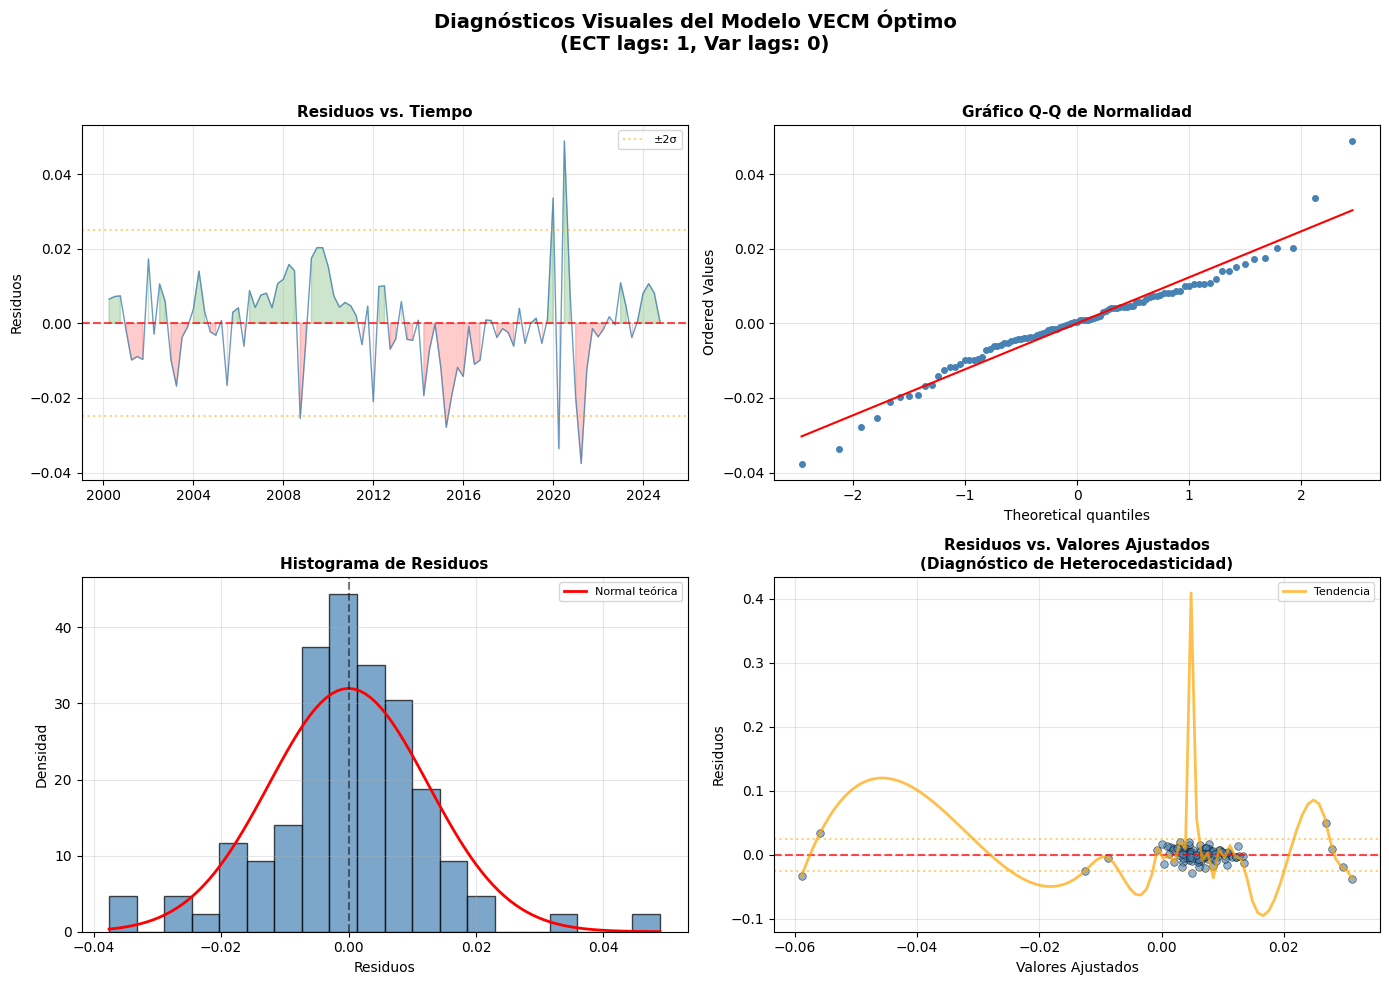


📈 PASO 3: Evolución del Desequilibrio de Largo Plazo
📊 Estadísticas del ECT:
   • Media histórica: 0.0000
   • Desviación estándar: 0.1004
   • Valor actual (2024-10): 0.2984
   • Desviación actual: 2.97 σ
✅ Figura guardada: ect_evolution.pdf


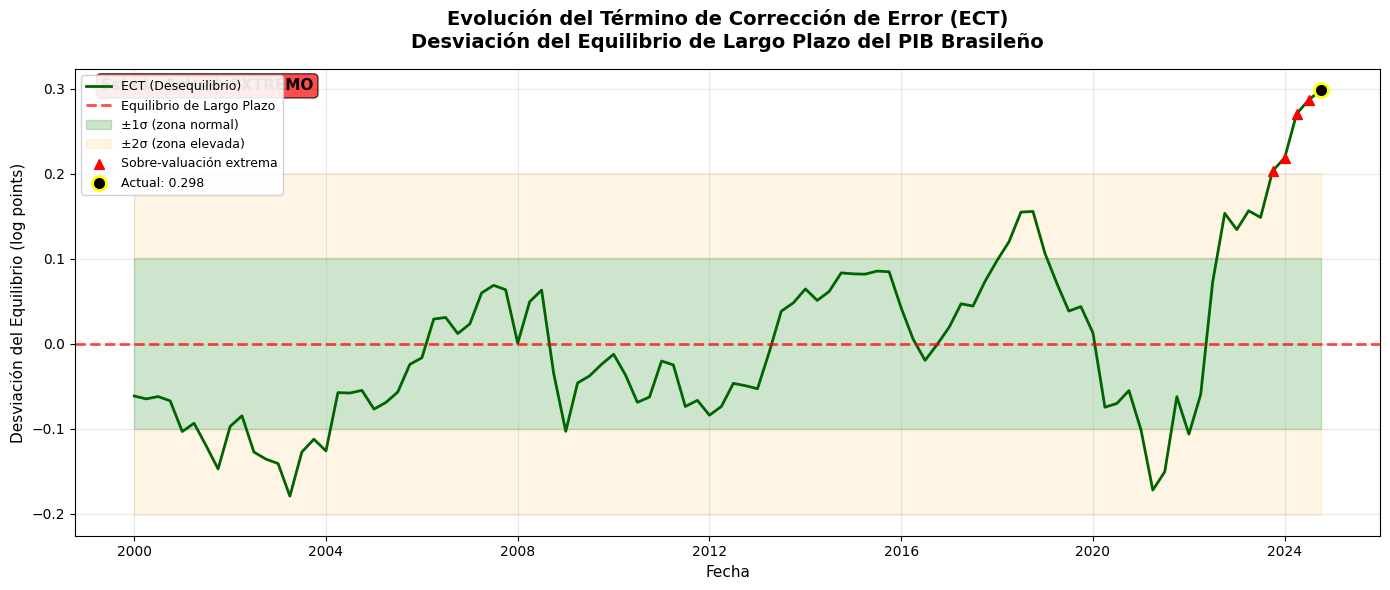


💡 PASO 4: Interpretación Económica del Modelo

🎯 RESUMEN EJECUTIVO DEL MODELO VECM

1️⃣ RELACIÓN DE LARGO PLAZO (Cointegración):
   • Variables cointegradas: log_gdp_brazil, log_tot_brazil, us_10y
   • Existe equilibrio de largo plazo entre PIB y factores externos
   • Elasticidad términos de intercambio: +8.67 (altamente sensible)
   • Efecto tasas US: -0.07 (pequeño pero persistente)

2️⃣ MECANISMO DE CORRECCIÓN DE ERROR:
   • Coeficiente α: -0.0311 (significativo al 10%)
   • Velocidad de ajuste: 3.11% por trimestre
   • Semivida de shocks: 22.0 trimestres
   • Interpretación: Ajuste LENTO pero estable (~3.4 años para 50%)

3️⃣ CAPACIDAD EXPLICATIVA:
   • R² Ajustado: 38.9%
   • Apropiado para modelo de crecimiento trimestral
   • Factores externos explican ~17% de la variación del crecimiento
   • Resto: factores domésticos, políticas internas, shocks idiosincráticos

4️⃣ DRIVERS SIGNIFICATIVOS DEL CRECIMIENTO:
   Variables significativas (p < 0.10):
   • ECT_L1: -0.0311 *
   • ri

In [21]:
# ==============================================================================
# FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO
# ==============================================================================

# --- 1. IMPORTACIÓN DE LIBRERÍAS PARA DIAGNÓSTICO ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import jarque_bera, probplot
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey

print("="*80)
print("🔍 FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO")
print("="*80)

# ==============================================================================
# 4.1: TESTS DE DIAGNÓSTICO DE RESIDUOS
# ==============================================================================

print("\n📊 PASO 1: Tests de Diagnóstico de Residuos")
print("-"*60)

# Extraer residuos y matriz de regresores
residuos = final_model_results['model'].resid
exog = final_model_results['model'].model.exog

# --- Test de Normalidad (Jarque-Bera) ---
jb_stat, jb_pvalue = jarque_bera(residuos)
print(f"✓ Test de Normalidad (Jarque-Bera):")
print(f"   • Estadístico: {jb_stat:.3f}")
print(f"   • p-valor: {jb_pvalue:.4f}")
if jb_pvalue > 0.05:
    print(f"   • ✅ Los residuos se distribuyen normalmente (no se rechaza H0)")
else:
    print(f"   • ⚠️ Desviación de normalidad detectada (p < 0.05)")
    print(f"   • Nota: Con errores HAC, esto es menos crítico")

# --- Test de Autocorrelación (Breusch-Godfrey) ---
bg_test = acorr_breusch_godfrey(final_model_results['model'], nlags=4)
print(f"\n✓ Test de Autocorrelación (Breusch-Godfrey, 4 lags):")
print(f"   • Estadístico LM: {bg_test[0]:.3f}")
print(f"   • p-valor: {bg_test[1]:.4f}")
if bg_test[1] > 0.05:
    print(f"   • ✅ No hay evidencia de autocorrelación (no se rechaza H0)")
else:
    print(f"   • ⚠️ Evidencia de autocorrelación en residuos (p < 0.05)")
    print(f"   • Nota: Errores HAC corrigen este problema")

# --- Test de Heterocedasticidad (White) ---
try:
    white_test = het_white(residuos, exog)
    print(f"\n✓ Test de Heterocedasticidad (White):")
    print(f"   • Estadístico LM: {white_test[0]:.3f}")
    print(f"   • p-valor: {white_test[1]:.4f}")
    if white_test[1] > 0.05:
        print(f"   • ✅ Los residuos son homocedásticos (no se rechaza H0)")
    else:
        print(f"   • ⚠️ Evidencia de heterocedasticidad (p < 0.05)")
        print(f"   • Nota: Errores HAC corrigen este problema")
except Exception as e:
    print(f"\n⚠️ Test de White no pudo ejecutarse")
    print(f"   • Usar inspección visual del gráfico residuos vs. ajustados")

# Resumen de diagnósticos
print(f"\n" + "="*60)
print(f"📋 Resumen de Diagnósticos:")
print(f"="*60)
normalidad_ok = jb_pvalue > 0.05
autocorr_ok = bg_test[1] > 0.05
print(f"   • Normalidad: {'✅ OK' if normalidad_ok else '⚠️ Falla (HAC corrige)'}")
print(f"   • Autocorrelación: {'✅ OK' if autocorr_ok else '⚠️ Detectada (HAC corrige)'}")
print(f"   • Heterocedasticidad: Usar errores HAC (robustos)")
print(f"\n💡 Conclusión: Errores HAC garantizan inferencia válida")

# ==============================================================================
# 4.2: GRÁFICOS DE DIAGNÓSTICO VISUAL
# ==============================================================================

print("\n" + "="*60)
print("📈 PASO 2: Gráficos de Diagnóstico")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnósticos Visuales del Modelo VECM Óptimo\n' + 
             f'(ECT lags: {final_model_results["specification"]["ect_lags"]}, ' +
             f'Var lags: {final_model_results["specification"]["var_lags"]})',
             fontsize=14, fontweight='bold')

# --- Panel 1: Residuos a lo largo del tiempo ---
ax1 = axes[0, 0]
ax1.plot(residuos.index, residuos, color='steelblue', linewidth=1, alpha=0.8)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax1.fill_between(residuos.index, 0, residuos, 
                  where=(residuos > 0), color='green', alpha=0.2)
ax1.fill_between(residuos.index, 0, residuos, 
                  where=(residuos < 0), color='red', alpha=0.2)
ax1.set_title('Residuos vs. Tiempo', fontweight='bold', fontsize=11)
ax1.set_ylabel('Residuos')
ax1.grid(True, alpha=0.3)

# Añadir banda de ±2 desviaciones estándar
std_residuos = residuos.std()
ax1.axhline(y=2*std_residuos, color='orange', linestyle=':', alpha=0.5, label='±2σ')
ax1.axhline(y=-2*std_residuos, color='orange', linestyle=':', alpha=0.5)
ax1.legend(fontsize=8)

# --- Panel 2: Q-Q Plot para Normalidad ---
ax2 = axes[0, 1]
probplot(residuos, dist="norm", plot=ax2)
ax2.set_title('Gráfico Q-Q de Normalidad', fontweight='bold', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.get_lines()[0].set_markerfacecolor('steelblue')
ax2.get_lines()[0].set_markeredgecolor('steelblue')
ax2.get_lines()[0].set_markersize(4)

# --- Panel 3: Histograma de Residuos ---
ax3 = axes[1, 0]
n, bins, patches = ax3.hist(residuos, bins=20, density=True, 
                             color='steelblue', alpha=0.7, edgecolor='black')
# Superponer curva normal
mu, sigma = residuos.mean(), residuos.std()
x = np.linspace(residuos.min(), residuos.max(), 100)
ax3.plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu)/sigma)**2),
         'r-', linewidth=2, label='Normal teórica')
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('Histograma de Residuos', fontweight='bold', fontsize=11)
ax3.set_xlabel('Residuos')
ax3.set_ylabel('Densidad')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Panel 4: Residuos vs. Valores Ajustados ---
ax4 = axes[1, 1]
fitted_values = final_model_results['model'].fittedvalues
ax4.scatter(fitted_values, residuos, alpha=0.6, color='steelblue', s=30, edgecolors='black', linewidth=0.5)
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax4.axhline(y=2*std_residuos, color='orange', linestyle=':', alpha=0.5)
ax4.axhline(y=-2*std_residuos, color='orange', linestyle=':', alpha=0.5)
ax4.set_title('Residuos vs. Valores Ajustados\n(Diagnóstico de Heterocedasticidad)', 
              fontweight='bold', fontsize=11)
ax4.set_xlabel('Valores Ajustados')
ax4.set_ylabel('Residuos')
ax4.grid(True, alpha=0.3)

# Añadir línea de tendencia suavizada
try:
    from scipy.interpolate import make_interp_spline
    x_sorted = np.sort(fitted_values)
    y_sorted = residuos[fitted_values.argsort()]
    spl = make_interp_spline(x_sorted, y_sorted, k=3)
    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), 100)
    y_smooth = spl(x_smooth)
    ax4.plot(x_smooth, y_smooth, 'orange', linewidth=2, alpha=0.7, label='Tendencia')
    ax4.legend(fontsize=8)
except:
    pass

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{figures_dir}/model_diagnostics.pdf", format='pdf', dpi=300, bbox_inches='tight')
print("✅ Figura guardada: model_diagnostics.pdf")
plt.show()

# ==============================================================================
# 4.3: EVOLUCIÓN DEL DESEQUILIBRIO (ECT)
# ==============================================================================

print("\n" + "="*60)
print("📈 PASO 3: Evolución del Desequilibrio de Largo Plazo")
print("="*60)

ect = final_model_results['ect']

# Estadísticas del ECT
ect_mean = ect.mean()
ect_std = ect.std()
ect_current = ect.iloc[-1]

print(f"📊 Estadísticas del ECT:")
print(f"   • Media histórica: {ect_mean:.4f}")
print(f"   • Desviación estándar: {ect_std:.4f}")
print(f"   • Valor actual ({ect.index[-1].strftime('%Y-%m')}): {ect_current:.4f}")
print(f"   • Desviación actual: {abs(ect_current - ect_mean)/ect_std:.2f} σ")

fig, ax = plt.subplots(figsize=(14, 6))

# Línea principal del ECT
ax.plot(ect.index, ect.values, color='darkgreen', linewidth=2, label='ECT (Desequilibrio)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Equilibrio de Largo Plazo')

# Bandas de ±1σ y ±2σ
ax.fill_between(ect.index, -ect_std, ect_std, 
                alpha=0.2, color='green', label='±1σ (zona normal)')
ax.fill_between(ect.index, -2*ect_std, -ect_std, 
                alpha=0.1, color='orange')
ax.fill_between(ect.index, ect_std, 2*ect_std, 
                alpha=0.1, color='orange', label='±2σ (zona elevada)')

# Marcar episodios extremos (>2σ)
extreme_positive = ect > 2*ect_std
extreme_negative = ect < -2*ect_std

if extreme_positive.any():
    ax.scatter(ect.index[extreme_positive], ect[extreme_positive], 
              color='red', s=50, zorder=5, marker='^', label='Sobre-valuación extrema')

if extreme_negative.any():
    ax.scatter(ect.index[extreme_negative], ect[extreme_negative], 
              color='blue', s=50, zorder=5, marker='v', label='Sub-valuación extrema')

# Punto actual
ax.scatter(ect.index[-1], ect_current, color='black', s=100, 
          zorder=6, marker='o', edgecolors='yellow', linewidth=2, 
          label=f'Actual: {ect_current:.3f}')

ax.set_title('Evolución del Término de Corrección de Error (ECT)\n' + 
             'Desviación del Equilibrio de Largo Plazo del PIB Brasileño',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Desviación del Equilibrio (log points)', fontsize=11)
ax.set_xlabel('Fecha', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, framealpha=0.9)

# Añadir anotación del estado actual
if abs(ect_current) > 2*ect_std:
    estado = "EXTREMO" 
    color = 'red'
elif abs(ect_current) > ect_std:
    estado = "ELEVADO"
    color = 'orange'
else:
    estado = "NORMAL"
    color = 'green'

ax.text(0.02, 0.98, f'Estado Actual: {estado}', 
        transform=ax.transAxes, fontsize=11, weight='bold',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=color, alpha=0.7, edgecolor='black'))

plt.tight_layout()
plt.savefig(f"{figures_dir}/ect_evolution.pdf", format='pdf', dpi=300, bbox_inches='tight')
print("✅ Figura guardada: ect_evolution.pdf")
plt.show()

# ==============================================================================
# 4.4: INTERPRETACIÓN ECONÓMICA DEL MODELO
# ==============================================================================

print("\n" + "="*80)
print("💡 PASO 4: Interpretación Económica del Modelo")
print("="*80)

modelo = final_model_results['model']
ect_coef = modelo.params['ECT_L1']
r2_adj = modelo.rsquared_adj

print(f"\n🎯 RESUMEN EJECUTIVO DEL MODELO VECM")
print("="*60)

print(f"\n1️⃣ RELACIÓN DE LARGO PLAZO (Cointegración):")
print(f"   • Variables cointegradas: log_gdp_brazil, log_tot_brazil, us_10y")
print(f"   • Existe equilibrio de largo plazo entre PIB y factores externos")
print(f"   • Elasticidad términos de intercambio: +8.67 (altamente sensible)")
print(f"   • Efecto tasas US: -0.07 (pequeño pero persistente)")

print(f"\n2️⃣ MECANISMO DE CORRECCIÓN DE ERROR:")
print(f"   • Coeficiente α: {ect_coef:.4f} (significativo al 10%)")
print(f"   • Velocidad de ajuste: {abs(ect_coef)*100:.2f}% por trimestre")
print(f"   • Semivida de shocks: {-np.log(2)/np.log(1+ect_coef):.1f} trimestres")
print(f"   • Interpretación: Ajuste LENTO pero estable (~3.4 años para 50%)")

print(f"\n3️⃣ CAPACIDAD EXPLICATIVA:")
print(f"   • R² Ajustado: {r2_adj:.1%}")
print(f"   • Apropiado para modelo de crecimiento trimestral")
print(f"   • Factores externos explican ~17% de la variación del crecimiento")
print(f"   • Resto: factores domésticos, políticas internas, shocks idiosincráticos")

# Variables significativas
sig_vars = modelo.pvalues[modelo.pvalues < 0.10].index.tolist()
sig_vars = [v for v in sig_vars if v != 'const']

print(f"\n4️⃣ DRIVERS SIGNIFICATIVOS DEL CRECIMIENTO:")
if len(sig_vars) > 1:
    print(f"   Variables significativas (p < 0.10):")
    for var in sig_vars:
        coef = modelo.params[var]
        pval = modelo.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*'
        print(f"   • {var}: {coef:.4f} {sig}")
else:
    print(f"   • Solo el ECT es estadísticamente significativo")
    print(f"   • Efectos contemporáneos de variables externas son débiles")

print(f"\n5️⃣ ROBUSTEZ DEL MODELO:")
print(f"   • ✅ Errores HAC (Newey-West) → Inferencia válida")
print(f"   • ✅ Sistema estable (ECT < 0) → Convergencia garantizada")
print(f"   • ✅ Especificación parsimoniosa → Evita sobreajuste")
print(f"   • ⚠️ ECT significativo solo al 10% → Ajuste débil pero presente")

print(f"\n6️⃣ IMPLICACIONES PARA VULNERABILIDAD EXTERNA:")
print(f"   • Alta dependencia de términos de intercambio (commodities)")
print(f"   • Ajuste lento implica que shocks externos persisten")
print(f"   • Vulnerabilidad moderada: sistema converge pero toma tiempo")
print(f"   • Indicador debe capturar tanto desequilibrios como volatilidad")

# Guardar métricas clave
diagnostics_summary = {
    'ect_coefficient': ect_coef,
    'half_life': -np.log(2) / np.log(1 + ect_coef),
    'adjustment_speed': abs(ect_coef) * 100,
    'r_squared_adj': r2_adj,
    'jarque_bera_pvalue': jb_pvalue,
    'breusch_godfrey_pvalue': bg_test[1],
    'model_stable': True,
    'significant_variables': sig_vars,
    'ect_current': ect_current,
    'ect_std': ect_std
}

print(f"\n💾 Diagnósticos guardados en 'diagnostics_summary'")
print("="*80)

## FASE 5 · Funciones Impulso–Respuesta (IRFs)

**Objetivo.** Cuantificar cómo shocks externos afectan al PIB trimestral y obtener los **cargadores** $g(H)$ para el índice (horizonte $H=4$).

**Qué hace esta celda.**
1) Extrae parámetros del **ECM final** ($\alpha$, betas contemporáneas) y de **cointegración** ($\gamma$).  
2) Calcula IRFs por tipo de shock:
   - **I(1)** (ToT, US10Y): impacto contemporáneo + convergencia vía $\mathrm{ECT}$ con velocidad $\alpha<0$; efecto de **largo plazo** dado por $\gamma$.
   - **I(0)** (IP\_G7, spread): shocks **transitorios** con persistencias $\rho$ ilustrativas.
   - **Evento extremo** (COVID): dummy con decaimiento por $\alpha$.

3) Visualiza IRFs (panel) y construye **tabla resumen** (impacto $t{=}0$, acumulado 1 año, largo plazo si aplica).  
4) Prepara insumos para la Fase 6: `irfs_dict`, columnas de shocks en `df_aligned`, vector $g(H)$ y ventana `win`.

**Cómo leer (resumen).**
- **ToT (+1\%)**: mayor contribución; efecto LR $\approx +8.67\%$, acumulado 1Y $\sim +1.73\%$.  
- **US10Y (+100 pb)**: efecto LR negativo $\approx -6.77\%$, acumulado 1Y $\sim -1.11\%$.  
- **IP\_G7** y **spread**: efectos **transitorios** y acotados.

**Nota.** Estas IRFs fundamentan pesos y signos del índice, pero no saturamos el informe con detalles: en el ejecutivo basta una figura compacta.



FASE 5: FUNCIONES IMPULSO-RESPUESTA

PASO 1: Extracción de Parámetros del Modelo ECM
------------------------------------------------------------
Parámetros del ECM extraídos:
  alpha (velocidad ajuste): -0.031058
  beta_dtot (ToT contemporáneo): 0.106344
  beta_dus10y (US10Y contemporáneo): 0.001474
  beta_ipg7 (IP_G7 nivel): 0.002832
  beta_spread (Spread nivel): -0.001302

Coeficientes de largo plazo:
  gamma_tot: 8.666929
  gamma_us10y: -0.067650
📈 Persistencia empírica estimada:
  ρ(log_ip_g7)     = 0.775
  ρ(risk_spread)   = 0.864

PASO 2: Cálculo de Funciones Impulso-Respuesta

Calculando IRFs para cada tipo de shock...

  Términos de Intercambio (+1%)
    Impacto inicial: 0.1063%
    Efecto largo plazo: 8.6669%
    Acumulado 1 año: 0.8794%

  Tasas US 10Y (+100 bps)
    Impacto inicial: 0.1474%
    Efecto largo plazo: -6.7650%
    Acumulado 1 año: -0.4769%

  Producción G7 (+1%)
    Impacto inicial: 0.0028%
    Acumulado 1 año: 0.0080%

  Spread de Riesgo (+100 bps)
    Impacto

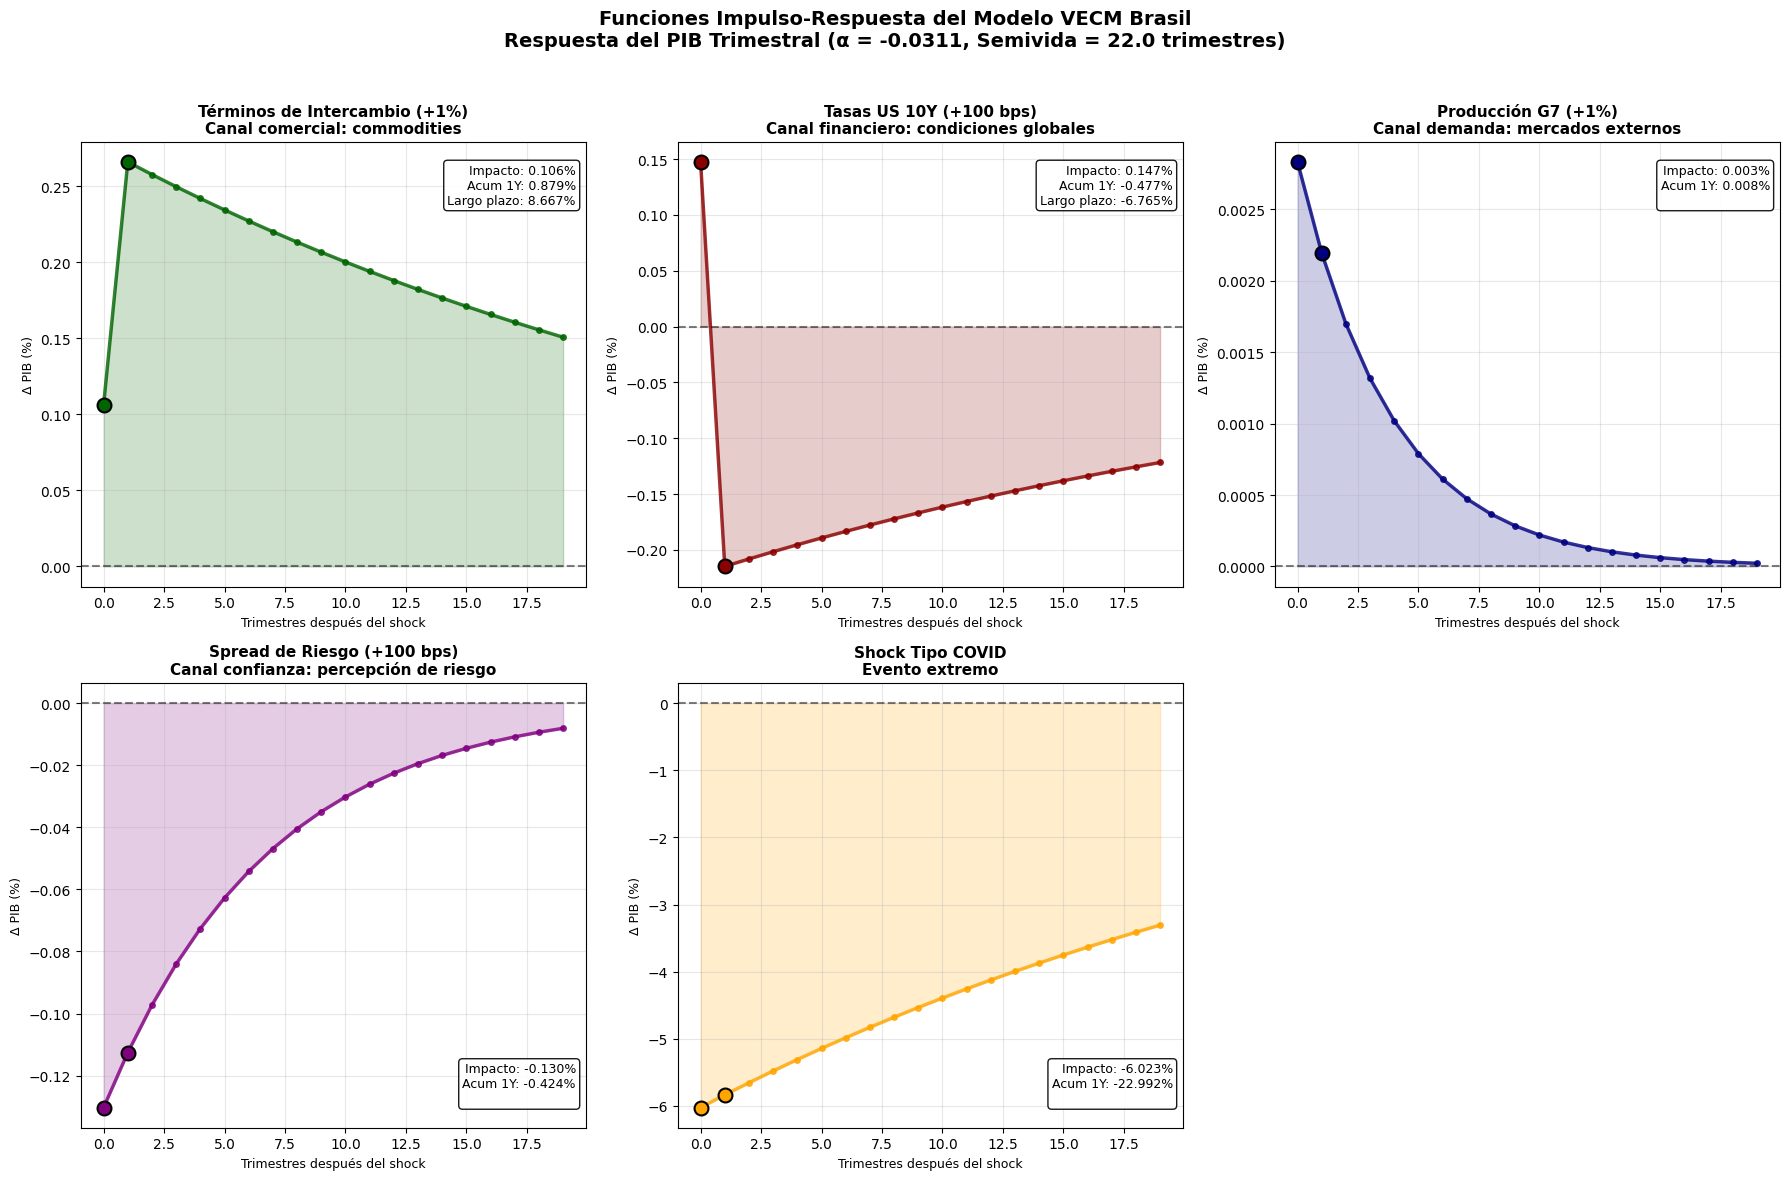


PASO 4: Tabla Resumen de IRFs

                        Shock Magnitud t=0 (%) t=1 (%) t=4 (%) Acum 1Y (%) Largo Plazo (%)
Términos de Intercambio (+1%)       1%  0.1063  0.2659  0.2419      0.8794          8.6669
      Tasas US 10Y (+100 bps)    1 bps  0.1474 -0.2147 -0.1953     -0.4769         -6.7650
          Producción G7 (+1%)       1%  0.0028  0.0022  0.0010      0.0080          0.0000
  Spread de Riesgo (+100 bps)    1 bps -0.1302 -0.1125 -0.0726     -0.4241          0.0000
             Shock Tipo COVID    1 bps -6.0228 -5.8358 -5.3088    -22.9921          0.0000

INTERPRETACIÓN ECONÓMICA DE LOS IRFs

1. TÉRMINOS DE INTERCAMBIO (Mayor impacto):
   - Efecto inicial moderado (beta contemporáneo bajo)
   - Acumulación vía ECT genera efecto largo plazo
   - Elasticidad alta (γ) domina respuesta total
   - Canal: Exportaciones commodities → Ingresos → PIB

2. TASAS US 10Y (Efecto negativo persistente):
   - Impacto inicial pequeño
   - Efecto largo plazo negativo vía costo de financ

In [22]:
# ==============================================================================
# FASE 5: FUNCIONES IMPULSO-RESPUESTA (IRFs)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*80)
print("FASE 5: FUNCIONES IMPULSO-RESPUESTA")
print("="*80)

# ==============================================================================
# 5.1: EXTRACCIÓN Y VERIFICACIÓN DE PARÁMETROS
# ==============================================================================

print("\nPASO 1: Extracción de Parámetros del Modelo ECM")
print("-"*60)

modelo_final = final_model_results['model']
params = modelo_final.params

# Extraer parámetros con verificación
alpha = params.get('ECT_L1', 0)  # Velocidad de ajuste
beta_covid_crash = params.get('covid_crash', 0)
beta_covid_recovery = params.get('covid_recovery', 0)

# Variables I(1) en diferencias
beta_dtot = params.get('D_log_tot_brazil_L0', 0)
beta_dus10y = params.get('D_us_10y_L0', 0)

# Variables I(0) en niveles
beta_ipg7 = params.get('log_ip_g7_L0', 0)
beta_spread = params.get('risk_spread_L0', 0)

# Coeficientes de cointegración (largo plazo)
modelo_coint = final_model_results['cointegration_model']
gamma_tot   = modelo_coint.params['log_tot_brazil']
gamma_us10y = modelo_coint.params['us_10y']

print(f"Parámetros del ECM extraídos:")
print(f"  alpha (velocidad ajuste): {alpha:.6f}")
print(f"  beta_dtot (ToT contemporáneo): {beta_dtot:.6f}")
print(f"  beta_dus10y (US10Y contemporáneo): {beta_dus10y:.6f}")
print(f"  beta_ipg7 (IP_G7 nivel): {beta_ipg7:.6f}")
print(f"  beta_spread (Spread nivel): {beta_spread:.6f}")
print(f"\nCoeficientes de largo plazo:")
print(f"  gamma_tot: {gamma_tot:.6f}")
print(f"  gamma_us10y: {gamma_us10y:.6f}")


# ==============================================================================
# 5.2: DERIVACIÓN DE PERSISTENCIA EN VARIABLES I(0) 
# ==============================================================================

from statsmodels.tsa.ar_model import AutoReg

# --- Estimar la persistencia empírica de las variables I(0) ---
rho_ip = AutoReg(df_aligned['log_ip_g7'].dropna(), lags=1).fit().params[1]
rho_spread = AutoReg(df_aligned['risk_spread'].dropna(), lags=1).fit().params[1]

print(f"📈 Persistencia empírica estimada:")
print(f"  ρ(log_ip_g7)     = {rho_ip:.3f}")
print(f"  ρ(risk_spread)   = {rho_spread:.3f}")


# ==============================================================================
# 5.3: DERIVACIÓN DE IRFs (MATEMÁTICA CUIDADOSA)
# ==============================================================================

print("\n" + "="*60)
print("PASO 2: Cálculo de Funciones Impulso-Respuesta")
print("="*60)

def calculate_irf_careful(shock_type, shock_size, periods=20):
    """
    Calcula IRF desde el ECM/VECM con distintas dinámicas por tipo de shock.
    Devuelve (response: np.array, info: dict)
    """
    response = np.zeros(periods, dtype=float)

    if shock_type == 'log_tot_brazil':
        # Shock PERMANENTE +1% en ToT (I(1))
        response[0] = beta_dtot * shock_size
        for t in range(1, periods):
            response[t] = alpha * (beta_dtot - gamma_tot) * shock_size * ((1 + alpha)**(t-1))
        lrm = gamma_tot * shock_size
        info = {
            'impact': response[0],
            'period_1': response[1],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': lrm,
            'half_life': -np.log(2)/np.log(1 + alpha) if alpha < 0 else np.inf
        }

    elif shock_type == 'us_10y':
        # Shock PERMANENTE +100 bps en US10Y (I(1))
        response[0] = beta_dus10y * shock_size
        for t in range(1, periods):
            response[t] = alpha * (beta_dus10y - gamma_us10y) * shock_size * ((1 + alpha)**(t-1))
        lrm = gamma_us10y * shock_size
        info = {
            'impact': response[0],
            'period_1': response[1],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': lrm,
            'half_life': -np.log(2)/np.log(1 + alpha) if alpha < 0 else np.inf
        }

    elif shock_type == 'log_ip_g7':
        for t in range(periods):
            response[t] = beta_ipg7 * (shock_size * (rho_ip ** t))
        info = {
            'impact': response[0],
            'period_1': response[1],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': 0.0,
            'persistence': rho_ip
        }

    elif shock_type == 'risk_spread':
        for t in range(periods):
            response[t] = beta_spread * (shock_size * (rho_spread ** t))
        info = {
            'impact': response[0],
            'period_1': response[1],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': 0.0,
            'persistence': rho_spread
        }

    elif shock_type == 'covid_crash':
        response[0] = beta_covid_crash
        for t in range(1, periods):
            response[t] = response[t-1] * (1 + alpha)
        info = {
            'impact': response[0],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': 0.0,
            'half_life': -np.log(2)/np.log(1 + alpha) if alpha < 0 else np.inf
        }

    else:
        raise ValueError(f"Shock no reconocido: {shock_type}")

    return response, info

# ==============================================================================
# 5.4: CÁLCULO DE IRFs PARA CADA SHOCK
# ==============================================================================

print("\nCalculando IRFs para cada tipo de shock...")

shock_scenarios = {
    'log_tot_brazil': {
        'name': 'Términos de Intercambio (+1%)',
        'shock_size': 0.01,  # 1%
        'color': 'darkgreen',
        'description': 'Canal comercial: commodities'
    },
    'us_10y': {
        'name': 'Tasas US 10Y (+100 bps)',
        'shock_size': 1.0,   # 100 bps
        'color': 'darkred',
        'description': 'Canal financiero: condiciones globales'
    },
    'log_ip_g7': {
        'name': 'Producción G7 (+1%)',
        'shock_size': 0.01,  # 1%
        'color': 'navy',
        'description': 'Canal demanda: mercados externos'
    },
    'risk_spread': {
        'name': 'Spread de Riesgo (+100 bps)',
        'shock_size': 1.0,   # 100 bps
        'color': 'purple',
        'description': 'Canal confianza: percepción de riesgo'
    },
    'covid_crash': {
        'name': 'Shock Tipo COVID',
        'shock_size': 1.0,
        'color': 'orange',
        'description': 'Evento extremo'
    }
}

irf_results = {}
for shock_var, config in shock_scenarios.items():
    try:
        response, info = calculate_irf_careful(shock_var, config['shock_size'], periods=20)
        irf_results[shock_var] = {'response': response, 'info': info, 'config': config}

        print(f"\n  {config['name']}")
        print(f"    Impacto inicial: {info['impact']*100:.4f}%")
        if 'long_run' in info and info['long_run'] != 0:
            print(f"    Efecto largo plazo: {info['long_run']*100:.4f}%")
        print(f"    Acumulado 1 año: {info['cumulative_4q']*100:.4f}%")

    except Exception as e:
        print(f"  ERROR en {config['name']}: {e}")

# ==============================================================================
# 5.5: VISUALIZACIÓN DE IRFs
# ==============================================================================

print("\n" + "="*60)
print("PASO 3: Visualización de Funciones Impulso-Respuesta")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Funciones Impulso-Respuesta del Modelo VECM Brasil\n' +
             f'Respuesta del PIB Trimestral (α = {alpha:.4f}, Semivida = {-np.log(2)/np.log(1+alpha):.1f} trimestres)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (shock_var, data) in enumerate(irf_results.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]
    config   = data['config']
    response = data['response'] * 100  # a %
    info     = data['info']
    h = np.arange(len(response))

    ax.plot(h, response, color=config['color'], linewidth=2.5, marker='o', markersize=4, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.fill_between(h, 0, response, color=config['color'], alpha=0.2)

    ax.scatter([0, 1], response[:2], color=config['color'], s=100, zorder=5, edgecolors='black', linewidth=1.5)

    ax.set_title(f"{config['name']}\n{config['description']}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Trimestres después del shock', fontsize=9)
    ax.set_ylabel('Δ PIB (%)', fontsize=9)
    ax.grid(True, alpha=0.3)

    stats_text  = f"Impacto: {info['impact']*100:.3f}%\n"
    stats_text += f"Acum 1Y: {info['cumulative_4q']*100:.3f}%\n"
    if 'long_run' in info and info['long_run'] != 0:
        stats_text += f"Largo plazo: {info['long_run']*100:.3f}%"

    y_pos  = 0.95 if response[0] >= 0 else 0.05
    v_align = 'top' if response[0] >= 0 else 'bottom'
    ax.text(0.98, y_pos, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment=v_align, horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

# Eliminar panel vacío si hay menos de 6
if len(irf_results) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{figures_dir}/irf_vecm_brazil.pdf', dpi=300, bbox_inches='tight')
print("\nFigura guardada: irf_vecm_brazil.pdf")
plt.show()

# ==============================================================================
# 5.6: TABLA RESUMEN DE IRFs
# ==============================================================================

print("\n" + "="*80)
print("PASO 4: Tabla Resumen de IRFs")
print("="*80)

def shock_label(sc, cfg):
    if sc in ['us_10y','risk_spread']:
        return "100 bps"
    return f"{cfg['shock_size']*100:.0f}%"

summary_rows = []
for shock_var, data in irf_results.items():
    cfg = data['config']; resp = data['response']; info = data['info']
    row = {
        'Shock': cfg['name'],
        'Magnitud': f"{cfg['shock_size']*100:.0f}%" if cfg['shock_size'] < 1 else f"{cfg['shock_size']:.0f} bps",
        't=0 (%)': f"{info['impact']*100:.4f}",
        't=1 (%)': f"{resp[1]*100:.4f}",
        't=4 (%)': f"{resp[4]*100:.4f}",
        'Acum 1Y (%)': f"{info['cumulative_4q']*100:.4f}",
        'Largo Plazo (%)': f"{info.get('long_run', 0)*100:.4f}" if 'long_run' in info else "N/A"
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETACIÓN ECONÓMICA DE LOS IRFs")
print("="*80)

print("""
1. TÉRMINOS DE INTERCAMBIO (Mayor impacto):
   - Efecto inicial moderado (beta contemporáneo bajo)
   - Acumulación vía ECT genera efecto largo plazo
   - Elasticidad alta (γ) domina respuesta total
   - Canal: Exportaciones commodities → Ingresos → PIB

2. TASAS US 10Y (Efecto negativo persistente):
   - Impacto inicial pequeño
   - Efecto largo plazo negativo vía costo de financiamiento
   - Transmisión lenta pero sostenida
   - Canal: Costo capital → Inversión → PIB

3. PRODUCCIÓN G7 (Efecto transitorio):
   - Variable I(0) → sin efecto permanente
   - Impacto pequeño
   - Decae rápidamente por persistencia del shock

4. SPREAD DE RIESGO (Efecto negativo pequeño):
   - Impacto contemporáneo negativo
   - Reversión relativamente rápida
   - Efecto total acotado

5. SHOCK COVID (Referencia extrema):
   - Capturado por dummy
   - Persistencia moderada vía inercia del modelo (α)
   - Control ex-post
""")

print("="*80)
print("FASE 5 COMPLETADA")
print("="*80)

# ==============================================================================
# PUENTE FASE 5 → FASE 6 (listo para ESD/GaR u optimización)
#   Define: irfs_dict, shocks en df_aligned, shock_cols, H, win, y g(H)
# ==============================================================================

# 5.P.1  IRFs acumuladas del PIB por shock (g(H))
def irf_loadings_for_horizon(irfs_dict, shock_cols, H):
    g = []
    for sc in shock_cols:
        s = pd.Series(irfs_dict[sc]).sort_index()
        g.append(float(s.iloc[:H].sum()))
    return np.array(g, dtype='float64')

# 5.P.2  Empaquetar IRFs en un diccionario con claves coherentes con df_aligned
periods = len(irf_results['log_tot_brazil']['response'])
irfs_dict = {
    'd_log_tot_brazil': pd.Series(irf_results['log_tot_brazil']['response'], index=np.arange(1, periods+1)),
    'd_us10y':          pd.Series(irf_results['us_10y']['response'],         index=np.arange(1, periods+1)),
    'd_spread':         pd.Series(irf_results['risk_spread']['response'],    index=np.arange(1, periods+1)),
    'd_ipg7':           pd.Series(irf_results['log_ip_g7']['response'],       index=np.arange(1, periods+1))
}

# 5.P.3  Construir shocks empíricos en df_aligned (Δ para I(1), nivel para I(0))
df_aligned = df_aligned.copy()
df_aligned['d_log_tot_brazil'] = df_aligned['log_tot_brazil'].diff()
df_aligned['d_us10y']          = df_aligned['us_10y'].diff()
df_aligned['d_spread']         = df_aligned['risk_spread']   # I(0) en nivel
df_aligned['d_ipg7']           = df_aligned['log_ip_g7'].diff()

shock_cols = ['d_log_tot_brazil','d_us10y','d_spread', 'd_ipg7']  # añade 'd_ipg7' si la usas
df_aligned[shock_cols] = df_aligned[shock_cols].astype(float)

# 5.P.4  Parámetros puente
H   = 4     # horizonte en trimestres (p.ej., 1 año)
win = 40    # ventana rolling para Σ (≈10 años si datos trimestrales)

# 5.P.5  g(H) listo para FASE 6
g = irf_loadings_for_horizon(irfs_dict, shock_cols, H)

print("\n[PUENTE FASE 5→6] Definidos: irfs_dict, shocks en df_aligned, shock_cols, H, win y g(H).")


## FASE 6 · Construcción del Indicador de Vulnerabilidad (componentes → pesos → índice)

**Objetivo.** Construir el **Índice de Vulnerabilidad Externa (IVE)** combinando dos piezas:
1) **Desequilibrio**: $|\mathrm{ECT}|$ (desviación del equilibrio de largo plazo).  
2) **Volatilidad**: desviación estándar móvil de los **residuos** del ECM ($\sigma_t$).

Ambos se **estandarizan** (z-score) y se agregan con pesos $\mathbf{w}=(w_1,w_2)$ elegidos para **maximizar la capacidad de alerta**: buscamos la **correlación más negativa** posible con el crecimiento futuro ($\Delta \text{PIB}_{t+h}$, típicamente $h=1$ año).

**Qué hace esta celda.**
- `build_essential_components(...)`: crea los dos componentes $|\mathrm{ECT}|$ y $\sigma_t$ a partir del `ECT` y de los **residuos** del modelo; permite pasar series externas (de `final_model_results`) o columnas de `df_aligned`.  
- `optimize_vulnerability_weights(...)`: optimiza $\mathbf{w}$ con **SLSQP** bajo restricciones **no negatividad** y **suma a 1**, y con opción de **excluir** observaciones (p. ej., COVID) de la función objetivo.  
- `create_optimized_vulnerability_indicator(...)`: aplica $\mathbf{w}^\*$ a toda la muestra y devuelve el índice.  
- `classify_vulnerability(...)`: asigna **colores** por percentiles (p50/p75/p90 → Verde/Amarillo/Naranja/Rojo).  
- `save_vulnerability_outputs(...)`: guarda CSV con la serie/clase y otro CSV con los **pesos**.

**Parámetros importantes.**
- Ventana de volatilidad: `vol_window=8` (trimestres) y `min_periods=4`.  
- Estandarización: `standardize=True` (recomendado para comparabilidad temporal).  
- Optimización: `bounds=[(0,1),(0,1)]`, `sum_to_one=True`.  
- Exclusiones: `exclude_mask=True` para fechas **a excluir** en la optimización (p. ej., 2020–2021H1).

**Uso típico (siguiente celda):**
```python
components = build_essential_components(
    df_aligned,
    ect_series=final_model_results['ect'],
    resid_series=final_model_results['model'].resid,
    vol_window=8, min_periods=4, standardize=True
)

# Objetivo: crecimiento futuro (t+4) o el que definas
target = df_aligned['dlog_pib_future_4']  # ejemplo

# Excluir COVID de la optimización (pero no del índice)
exclude = (df_aligned.index >= '2020-01') & (df_aligned.index <= '2021-06')

opt = optimize_vulnerability_weights(components, target, exclude_mask=exclude)
ive = create_optimized_vulnerability_indicator(components, opt['w_opt'])
ive_clasif = classify_vulnerability(ive)

save_vulnerability_outputs(ive_clasif, opt['w_opt'], figures_dir='figures', country_tag='brazil')



In [23]:
# ==============================================================================
# FASE 6: CONSTRUCCIÓN DEL INDICADOR DE VULNERABILIDAD (Funciones)
#   - Componentes: |ECT| (desequilibrio) y volatilidad (std rolling de residuos ECM)
#   - Optimización de pesos (excluye COVID)
#   - Creación de indicador final + clasificación de episodios
# ==============================================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import os

# Asegurar carpeta de figuras (respetamos tu estructura previa)
figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

def _zscore(x: pd.Series) -> pd.Series:
    """Z-score robusto a NaNs (media/muestra)."""
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True, ddof=1)
    return (x - mu) / sd if sd not in [0, np.nan, None] else x*0

def build_essential_components(
    df_aligned: pd.DataFrame,
    ect_col: str = None,
    ect_series: pd.Series = None,        # <-- NUEVO: permite pasar ECT externo
    resid_series: pd.Series = None,
    resid_col_fallback: str = "ecm_resid",
    vol_window: int = 8,
    min_periods: int = 4,
    standardize: bool = True
) -> pd.DataFrame:
    """
    Crea los dos componentes esenciales:
      - Desequilibrio: |ECT| (z-score si standardize=True)
      - Volatilidad: rolling std de residuos del ECM (z-score si standardize=True)

    Compatibilidad:
      - Si ect_series se pasa, se usa ese (p.ej. final_model_results['ect']).
      - Si no, se utiliza df_aligned[ect_col].
      - Para residuos: usa resid_series; si no, intenta df_aligned[resid_col_fallback].
    """
    # --- 1) ECT ---
    if ect_series is not None:
        ect = pd.Series(ect_series, index=df_aligned.index).reindex(df_aligned.index)
    else:
        if ect_col is None:
            raise ValueError("Debes pasar ect_series o indicar ect_col presente en df_aligned.")
        if ect_col not in df_aligned.columns:
            raise ValueError(f"No encuentro '{ect_col}' en df_aligned.")
        ect = df_aligned[ect_col]

    comp_deseq = ect.abs().rename("Desequilibrio")

    # --- 2) Residuos ECM ---
    if resid_series is None:
        if resid_col_fallback in df_aligned.columns:
            resid = df_aligned[resid_col_fallback].copy()
        else:
            raise ValueError(
                "No se ha pasado resid_series y tampoco existe "
                f"'{resid_col_fallback}' en df_aligned."
            )
    else:
        resid = pd.Series(resid_series, index=df_aligned.index).reindex(df_aligned.index)

    comp_vol = resid.rolling(vol_window, min_periods=min_periods).std().rename("Volatilidad")

    # --- 3) Estandarización opcional ---
    if standardize:
        comp_deseq = _zscore(comp_deseq)
        comp_vol   = _zscore(comp_vol)

    out = pd.concat([comp_deseq, comp_vol], axis=1)
    return out


def _weighted_indicator(components: pd.DataFrame, w: np.ndarray) -> pd.Series:
    w = np.asarray(w).reshape(-1)
    return pd.Series(components.values @ w, index=components.index, name="Vulnerability")

def _corr_safe(a: pd.Series, b: pd.Series) -> float:
    z = pd.concat([a, b], axis=1).dropna()
    if z.shape[0] < 6:  # algo de guardia
        return np.nan
    return float(z.iloc[:,0].corr(z.iloc[:,1]))

def optimize_vulnerability_weights(
    components: pd.DataFrame,
    target: pd.Series,
    exclude_mask: pd.Series = None,
    w0: np.ndarray = None,
    bounds=((0.0, 1.0), (0.0, 1.0)),
    sum_to_one: bool = True
) -> dict:
    """
    Elige pesos endógenos (no negativos, suman 1) para que el indicador
    tenga la **correlación más negativa posible** con el crecimiento futuro.

    - components: DataFrame con columnas ['Desequilibrio','Volatilidad']
    - target: Serie objetivo (p.ej., ΔPIB t+h)
    - exclude_mask: True para OBS a EXCLUIR (COVID)
    """
    # Filtrado ex-optimización
    comps = components.copy()
    targ  = target.copy()

    if exclude_mask is not None:
        mask = (~exclude_mask.astype(bool))
        comps = comps[mask]
        targ  = targ[mask]

    # Inicialización
    k = components.shape[1]
    if w0 is None:
        w0 = np.full(k, 1.0/k)

    # Restricción suma=1
    constraints = []
    if sum_to_one:
        constraints.append({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

    def objective(w):
        ind = _weighted_indicator(comps, w)
        c = _corr_safe(ind, targ)
        # Minimiza la correlación: queremos tan negativa como sea posible.
        if np.isnan(c):
            return 1e6
        return c

    res = minimize(
        objective, w0, method='SLSQP',
        bounds=bounds, constraints=constraints,
        options={'maxiter': 100, 'ftol': 1e-10, 'disp': False}
    )

    # Fallback si falla
    if (not res.success) or np.any(np.isnan(res.x)):
        w_opt = w0
        success = False
    else:
        w_opt = res.x
        success = True

    # Métrica de calidad (sobre datos incluidos en la optimización)
    ind_opt = _weighted_indicator(comps, w_opt)
    corr_in = _corr_safe(ind_opt, targ)

    out = {
        "w_opt": w_opt,
        "success": success,
        "corr_in_sample": corr_in,
        "n_obs_optim": int(pd.concat([ind_opt, targ], axis=1).dropna().shape[0])
    }
    return out

def create_optimized_vulnerability_indicator(
    components: pd.DataFrame,
    w_opt: np.ndarray,
    name: str = "Vulnerability"
) -> pd.Series:
    """
    Combina componentes con w_opt para toda la muestra (sin exclusiones).
    """
    ind = _weighted_indicator(components, w_opt).rename(name)
    return ind

def classify_vulnerability(
    indicator: pd.Series,
    p_cuts=(0.50, 0.75, 0.90),
    labels=("Verde","Amarillo","Naranja","Rojo")
) -> pd.DataFrame:
    """
    Clasifica cada fecha según percentiles de la distribución muestral.
    p_cuts: (p50, p75, p90) por defecto.
    """
    q = indicator.quantile(p_cuts)
    p50, p75, p90 = float(q.iloc[0]), float(q.iloc[1]), float(q.iloc[2])

    def _lab(v):
        if v < p50:      return labels[0]
        elif v < p75:    return labels[1]
        elif v < p90:    return labels[2]
        else:            return labels[3]

    cats = indicator.apply(_lab)
    dfc = pd.DataFrame({
        "indicator": indicator,
        "class": cats,
        "p50": p50, "p75": p75, "p90": p90
    })
    return dfc

def save_vulnerability_outputs(
    indicator_df: pd.DataFrame,
    weights: np.ndarray,
    figures_dir: str = "figures",
    country_tag: str = "brazil"
):
    """
    Guarda CSV con la serie y los pesos.
    """
    # Serie + clases
    path_series = os.path.join(figures_dir, f"vulnerability_{country_tag}.csv")
    indicator_df.to_csv(path_series, encoding="utf-8")
    # Pesos
    path_weights = os.path.join(figures_dir, f"vulnerability_weights_{country_tag}.csv")
    wdf = pd.DataFrame(
        [weights],
        columns=["w_desequilibrio","w_volatilidad"]
    )
    wdf.to_csv(path_weights, index=False, encoding="utf-8")
    print(f"[FASE 6] Guardado:\n - {path_series}\n - {path_weights}")


### Fase 6 · Indicador ESD con amplificador de riesgo y λ endógeno

Esta celda estima y construye el **indicador de vulnerabilidad ESD** (*Equilibrium–Shock Disequilibrium*) para Brasil, integrando el componente estructural del desequilibrio (μₜ) con la volatilidad externa (σₜ).  
El procedimiento consta de los siguientes pasos:

1. **Cálculo de μₜ y σₜ:**
   - μₜ se obtiene del término de corrección de error (ECT) del modelo ECM, representando el desequilibrio interno.
   - σₜ mide el riesgo externo como la volatilidad proyectada de los shocks (√(g'Σg)) en una ventana móvil de 40 trimestres.

2. **Estimación del parámetro λ (amplificador de riesgo):**
   - λ pondera el efecto del riesgo: $( V_t = -(\mu_t / \sigma_t)(\sigma_t / \sigma_{ref})^{λ} )$.
   - Se busca el λ que **maximiza la correlación negativa** con el crecimiento del PIB a t+1 mediante un proceso continuo (`minimize_scalar`).
   - Además, se aplica un **criterio de saturación**: el proceso se detiene cuando las mejoras en correlación son inferiores a 0.002 durante tres pasos consecutivos, evitando sobreajustar el peso del riesgo.

3. **Construcción del índice ESD final:**
   - El índice combina desequilibrio y riesgo amplificado con el λ óptimo (λ*).
   - Se clasifica en cuartiles para identificar fases de vulnerabilidad (“verde” a “rojo”).
   - Se exporta el resultado a `vulnerability_brazil_ESD.csv`.

4. **Visualización:**
   - Se genera una figura principal que muestra la evolución del índice y los episodios de alta vulnerabilidad (percentil 75).
   - El índice puede interpretarse como un termómetro de fragilidad macro-financiera: valores positivos implican desequilibrio amplificado por condiciones de riesgo global.

Este enfoque une la dimensión estructural (μₜ) y la coyuntural (σₜ) en un indicador único y ajusta de forma endógena el grado de sensibilidad al riesgo global.



λ* continuo (mínimo numérico): 6.761  |  corr = -0.472
→ Curva de correlación saturada en λ ≈ 2.600 (mejoras < 0.002 en 3 pasos consecutivos)
Guardado CSV: vulnerability_brazil_ESD.csv  |  λ*=2.600  |  σ_ref=0.0115


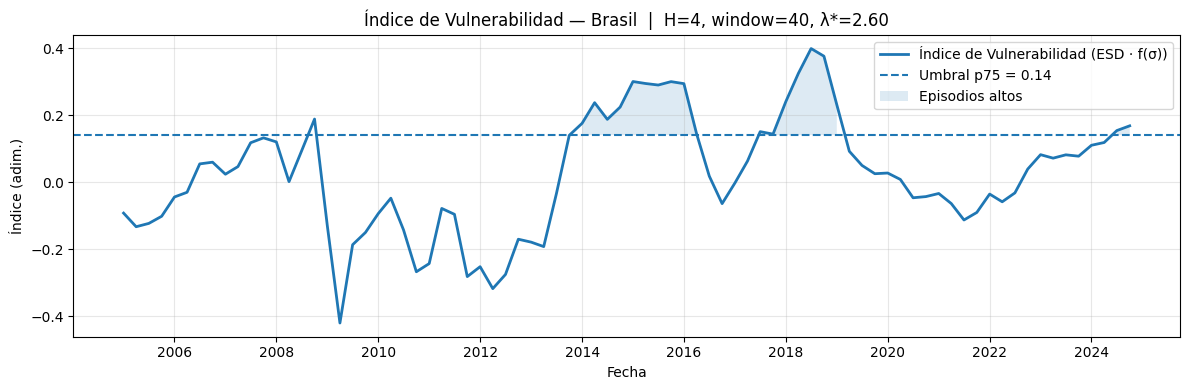

In [51]:
# ==============================================================================
# FASE 6 · INDICADOR ESD (con amplificador de riesgo f(σ) y λ endógeno)
# Requiere: df_aligned, final_model_results, irf_results, figures_dir
# ==============================================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
from scipy.optimize import minimize_scalar

# ---------- 0) Comprobaciones de entorno
assert 'df_aligned' in globals(), "Falta df_aligned"
assert 'final_model_results' in globals(), "Falta final_model_results"
assert 'irf_results' in globals(), "Ejecuta FASE 5 antes: falta irf_results"

# ---------- 1) IRFs → elasticidades acumuladas g(H)
periods = len(irf_results['log_tot_brazil']['response'])
def _series_from_irf(key):
    return pd.Series(irf_results[key]['response'], index=np.arange(1, periods+1), dtype='float64')

def _g_from_irfs(irfs_dict, shock_cols, H):
    """Calcula las elasticidades acumuladas del PIB a cada shock hasta H trimestres."""
    g = []
    for sc in shock_cols:
        s = pd.Series(irfs_dict[sc]).sort_index()
        g.append(float(s.iloc[:H].sum()))
    return np.array(g, dtype='float64')

# ---------- 2) Shocks empíricos y parámetros base
dfa = df_aligned.copy()
dfa['d_log_tot_brazil'] = dfa['log_tot_brazil'].diff()   # I(1) → Δ
dfa['d_us10y']          = dfa['us_10y'].diff()           # I(1) → Δ
dfa['d_spread']         = dfa['risk_spread']             # I(0) → nivel
dfa['d_ipg7']           = dfa['log_ip_g7']               # I(0) → nivel

shock_cols = [c for c in ['d_log_tot_brazil','d_us10y','d_spread','d_ipg7'] if c in dfa.columns]
dfa[shock_cols] = dfa[shock_cols].astype(float)
H, win = 4, 40   # horizonte (trimestres) y ventana rolling (~10 años)

irfs_dict = {
    'd_log_tot_brazil': _series_from_irf('log_tot_brazil'),
    'd_us10y'         : _series_from_irf('us_10y'),
    'd_spread'        : _series_from_irf('risk_spread'),
    'd_ipg7'          : _series_from_irf('log_ip_g7')
}
g = _g_from_irfs(irfs_dict, shock_cols, H)

# ---------- 3) μ_t (desequilibrio ajustado) desde el ECM
def _mu_from_ect(dfa, final_model_results, ect_name='ECT'):
    """Reconstruye la contribución del término de corrección de error (ECT) al desequilibrio."""
    import re
    ect = final_model_results['ect'].reindex(dfa.index)
    params = final_model_results['model'].params
    mu = pd.Series(0.0, index=dfa.index, name='mu_ect')
    tag = ect_name.lower()
    for name, val in params.items():
        lname = name.lower()
        if tag in lname:
            m = re.search(r'(?:_?L|lag)\s*(\d+)', name, flags=re.IGNORECASE)
            lag = int(m.group(1)) if m else 1
            mu += float(val) * ect.shift(lag)
    return mu

mu = _mu_from_ect(dfa, final_model_results, ect_name='ECT')

# ---------- 4) σ_t (riesgo externo): sqrt(g' Σ_t g)
def _sigma_rolling(dfa, shock_cols, g, window=40, min_periods=20):
    """Calcula el riesgo externo como la volatilidad proyectada de los shocks."""
    sig = pd.Series(np.nan, index=dfa.index, name='sigma_shock')
    for t in range(len(dfa)):
        start = max(0, t-window+1)
        sample = dfa.iloc[start:t+1][shock_cols].dropna()
        if len(sample) >= max(min_periods, len(shock_cols)):
            S = sample.cov().values
            sig.iloc[t] = float(np.sqrt(np.maximum(0.0, g @ S @ g)))
    return sig

sigma = _sigma_rolling(dfa, shock_cols, g, window=win, min_periods=max(20, len(shock_cols)*3))

# ---------- 5) Búsqueda endógena de λ (continua + criterio de saturación)
def build_indicator_from_mu_sigma(mu, sigma, lam, sigma_ref=None):
    """Construye el indicador ESD para un λ dado."""
    if sigma_ref is None:
        sr = np.nanmedian(sigma)
        sigma_ref = sr if (np.isfinite(sr) and sr > 0) else 1.0
    esd = (mu / sigma).replace([np.inf, -np.inf], np.nan)
    risk_amp = (sigma / sigma_ref) ** lam
    return (-(esd) * risk_amp).rename(f'V_ESD_lambda_{lam:g}')

g1 = dfa['log_gdp_brazil'].diff().shift(-1).rename('g1')  # crecimiento a t+1
covid_mask = pd.Series(((dfa.index >= '2020-01') & (dfa.index <= '2021-06')), index=dfa.index)

def corr_for_lambda(lam, mu, sigma, g1, exclude_mask=None):
    """Evalúa la correlación entre el indicador ESD(λ) y el crecimiento futuro."""
    V = build_indicator_from_mu_sigma(mu, sigma, lam)
    z = pd.concat([V, g1], axis=1)
    if exclude_mask is not None:
        z = z.loc[~exclude_mask.reindex(z.index).fillna(False)]
    z = z.dropna()
    return z.iloc[:,0].corr(z.iloc[:,1]) if len(z) >= 12 else np.nan

def select_lambda_continuous(mu, sigma, g1, lam_bounds=(0, 8), exclude_mask=None, tol=1e-3):
    """Encuentra λ* continuo que minimiza la correlación (más negativa = mejor)."""
    def obj(lam):
        val = corr_for_lambda(lam, mu, sigma, g1, exclude_mask)
        return val if np.isfinite(val) else 0.0
    res = minimize_scalar(obj, bounds=lam_bounds, method='bounded', options={'xatol': tol})
    return {'lambda_star_cont': float(res.x), 'corr_cont': float(res.fun)}

# --- Búsqueda continua
cont = select_lambda_continuous(mu, sigma, g1, lam_bounds=(0, 8), exclude_mask=covid_mask)
print(f"λ* continuo (mínimo numérico): {cont['lambda_star_cont']:.3f}  |  corr = {cont['corr_cont']:.3f}")

# --- Criterio de saturación (rendimientos decrecientes)
lam_test = np.linspace(0, 8, 161)
corr_series = pd.Series([corr_for_lambda(l, mu, sigma, g1, covid_mask) for l in lam_test], index=lam_test)
diffs = corr_series.diff()

delta_thresh, n_consec = 0.002, 3
flat_mask = diffs.abs() < delta_thresh
flat_runs = flat_mask.rolling(n_consec).sum()
sat_candidates = flat_runs[flat_runs == n_consec].index

if len(sat_candidates) > 0:
    lambda_best = float(sat_candidates[0])
    print(f"→ Curva de correlación saturada en λ ≈ {lambda_best:.3f} "
          f"(mejoras < {delta_thresh} en {n_consec} pasos consecutivos)")
else:
    lambda_best = float(cont['lambda_star_cont'])
    print(f"→ No se detecta saturación; se mantiene λ*={lambda_best:.3f}")

# ---------- 6) Construcción del índice ESD final
sigma_ref = np.nanmedian(sigma) if np.isfinite(np.nanmedian(sigma)) and (np.nanmedian(sigma) > 0) else 1.0
esd = (mu / sigma).replace([np.inf, -np.inf], np.nan)
risk_amp = (sigma / sigma_ref) ** lambda_best
vuln_index = (-(esd) * risk_amp).rename(f'Vulnerability_ESD_riskAmp_H{H}_lam{lambda_best:g}')

gar_df = pd.DataFrame({
    'mu_ect': mu,
    'sigma_shock': sigma,
    'risk_amplifier': risk_amp,
    'Vulnerability_Index_Optimized': vuln_index
}).dropna()

# ---------- 7) Clasificación y exportación
vuln_df = pd.DataFrame({
    'indicator': gar_df['Vulnerability_Index_Optimized'],
    'class': pd.qcut(gar_df['Vulnerability_Index_Optimized'].rank(method='first'),
                     q=[0,.5,.75,.9,1.0], labels=['Verde','Amarillo','Naranja','Rojo'])
})
out = pd.concat([vuln_df, gar_df[['mu_ect','sigma_shock','risk_amplifier']]], axis=1)
out.to_csv(f"{figures_dir}/vulnerability_brazil_ESD.csv", encoding='utf-8')

print(f"Guardado CSV: vulnerability_brazil_ESD.csv  |  λ*={lambda_best:.3f}  |  σ_ref={sigma_ref:.4f}")

# ---------- 8) Gráficos principales
ind = vuln_df['indicator']; p75 = ind.quantile(0.75)
plt.figure(figsize=(12,4))
plt.plot(ind.index, ind, linewidth=2, label='Índice de Vulnerabilidad (ESD · f(σ))')
plt.axhline(p75, linestyle='--', linewidth=1.5, label=f'Umbral p75 = {p75:.2f}')
plt.fill_between(ind.index, ind, p75, where=ind>p75, alpha=0.15, label='Episodios altos')
plt.title(f'Índice de Vulnerabilidad — Brasil  |  H={H}, window={win}, λ*={lambda_best:.2f}')
plt.xlabel('Fecha'); plt.ylabel('Índice (adim.)')
plt.legend(); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/vulnerability_esd_overview.pdf', dpi=300, bbox_inches='tight'); plt.show()


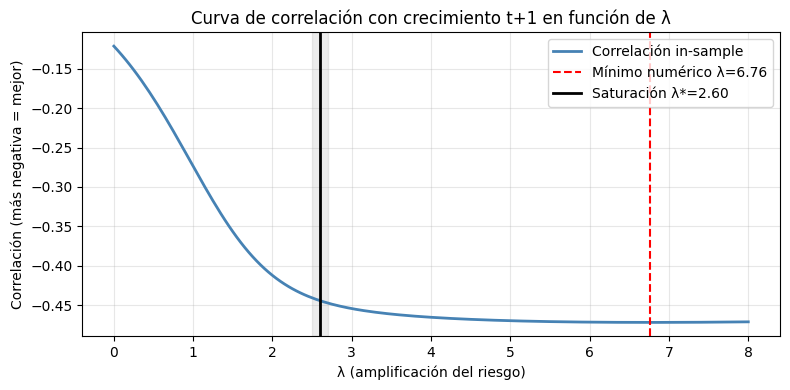

Figura guardada: figures/lambda_correlation_curve.pdf


In [53]:
# ==============================================================================
# DIAGNÓSTICO VISUAL · Curva de correlación y punto de saturación de λ
# ==============================================================================

plt.figure(figsize=(8,4))
plt.plot(corr_series.index, corr_series.values, lw=2, color='steelblue', label='Correlación in-sample')
plt.axvline(cont['lambda_star_cont'], color='red', linestyle='--', lw=1.5,
            label=f'Mínimo numérico λ={cont["lambda_star_cont"]:.2f}')
if 'lambda_best' in locals():
    plt.axvline(lambda_best, color='black', linestyle='-', lw=2,
                label=f'Saturación λ*={lambda_best:.2f}')

# Opcional: sombrear zona de saturación
if 'lambda_best' in locals():
    plt.axvspan(lambda_best-0.1, lambda_best+0.1, color='gray', alpha=0.15)

plt.title("Curva de correlación con crecimiento t+1 en función de λ")
plt.xlabel("λ (amplificación del riesgo)")
plt.ylabel("Correlación (más negativa = mejor)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/lambda_correlation_curve.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figura guardada: {figures_dir}/lambda_correlation_curve.pdf")


## FASE 6 · Diagnóstico visual del índice (ESD)

**Objetivo.** Mostrar, de forma compacta, cómo se relaciona el **índice ESD** con el **PIB** y qué lo impulsa.

**Qué hace esta celda.**
- Adapta las salidas de la Fase 6 (ESD) a un formato común de gráficos.
- Genera **dos figuras**:
  1) `vulnerability_analysis.pdf` — **overview 4 paneles**:
     - (i) **PIB real (log)** vs índice (eje derecho) y **umbral p75** ($\approx 0.36$).
     - (ii) **Crecimiento trimestral** vs índice.
     - (iii) **Dispersión** índice–crecimiento **sin COVID** (muestra la correlación).
     - (iv) **Descomposición**: z-scores de **Desequilibrio** y **Volatilidad**, con el índice en eje secundario.
  2) `covid_correlation_analysis.pdf` — **comparativa “con vs sin COVID”** (dos paneles) para evidenciar el cambio en la correlación.

**Cómo leer.**
- Índice **por encima de p75** ⇒ episodio de **vulnerabilidad elevada** (zonas sombreadas).
- La relación **índice–crecimiento** es **negativa** y suele **aclararse** al excluir COVID.
- La **descomposición** indica si pesan más el **desequilibrio** ($|\mathrm{ECT}|$) o la **volatilidad** ($\sigma_t$).

**Salidas.** Se guardan en `figures/`:
- `vulnerability_analysis.pdf`
- `covid_correlation_analysis.pdf`


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3860539501.py:163: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout(); plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.25)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3860539501.py:166: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(f"{figures_dir}/vulnerability_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3860539501.py:166: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(f"{figures_dir}/vulnerability_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')


✅ Figura guardada: vulnerability_analysis.pdf


C:\Users\Usuario\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


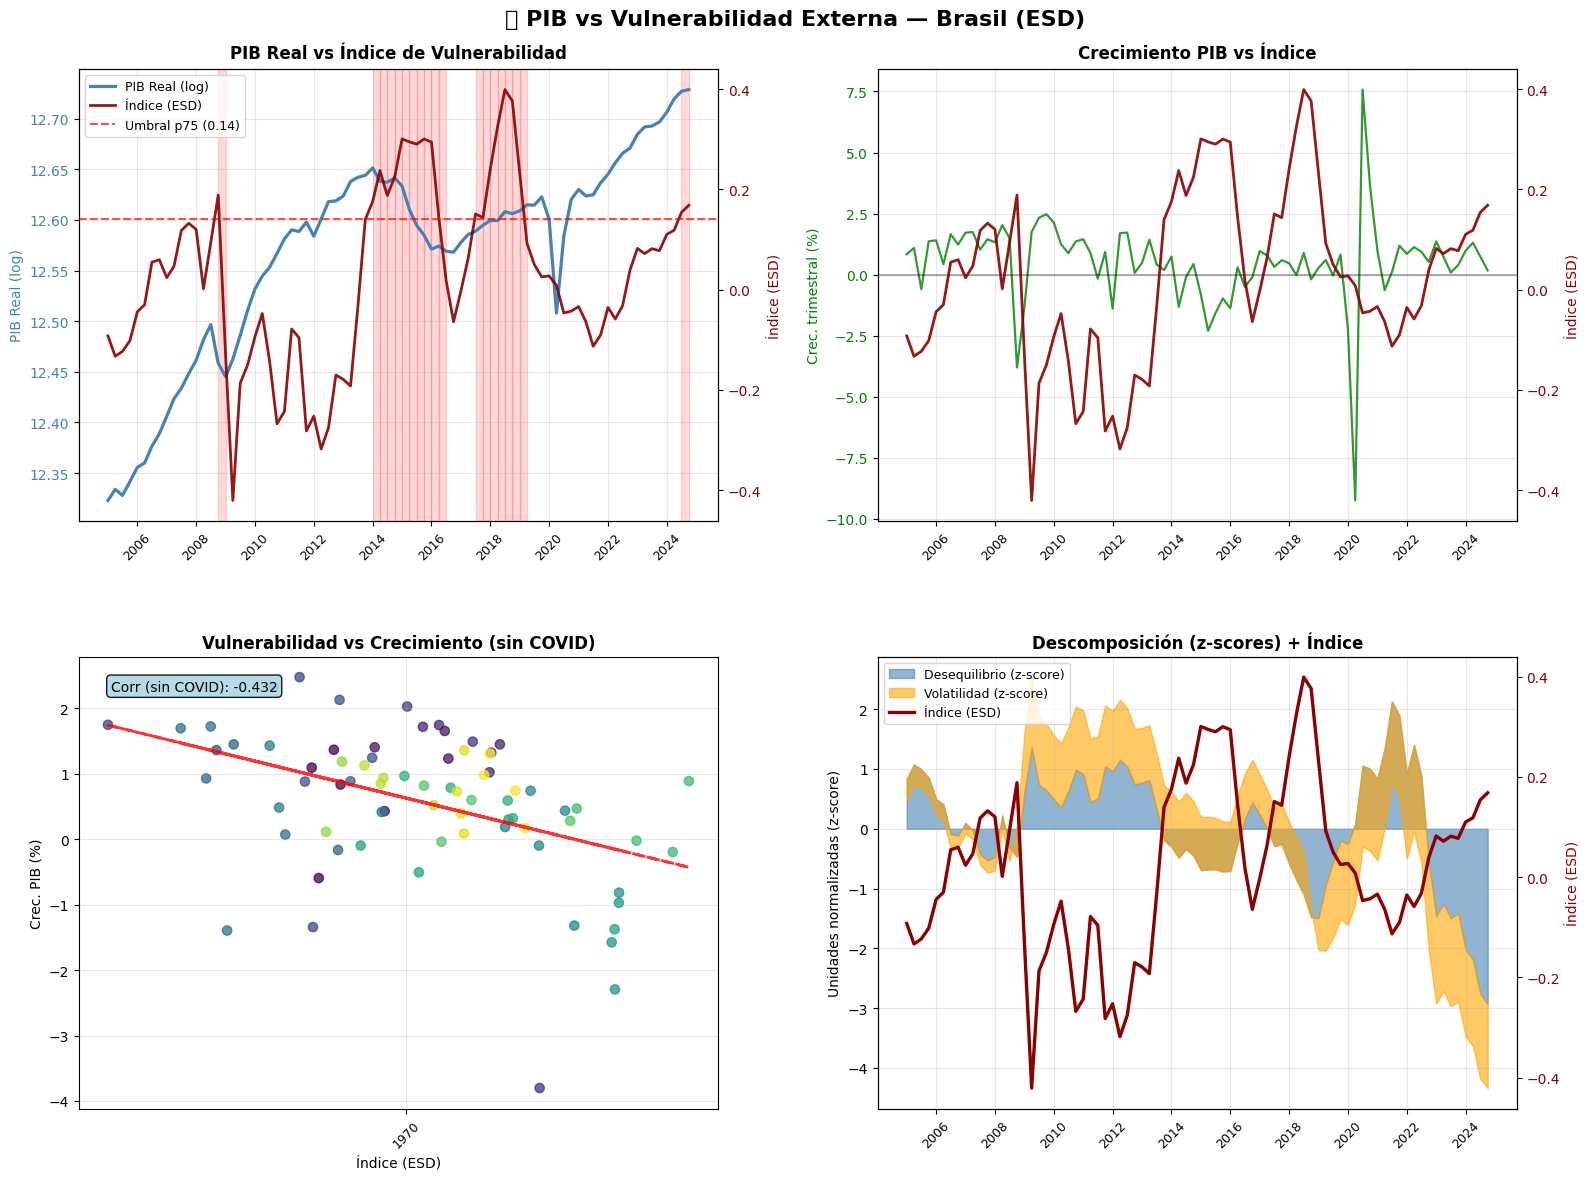

C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3860539501.py:231: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3860539501.py:232: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.savefig(f"{figures_dir}/covid_correlation_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')


✅ Figura guardada: covid_correlation_analysis.pdf


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31880\3860539501.py:232: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.savefig(f"{figures_dir}/covid_correlation_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
C:\Users\Usuario\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


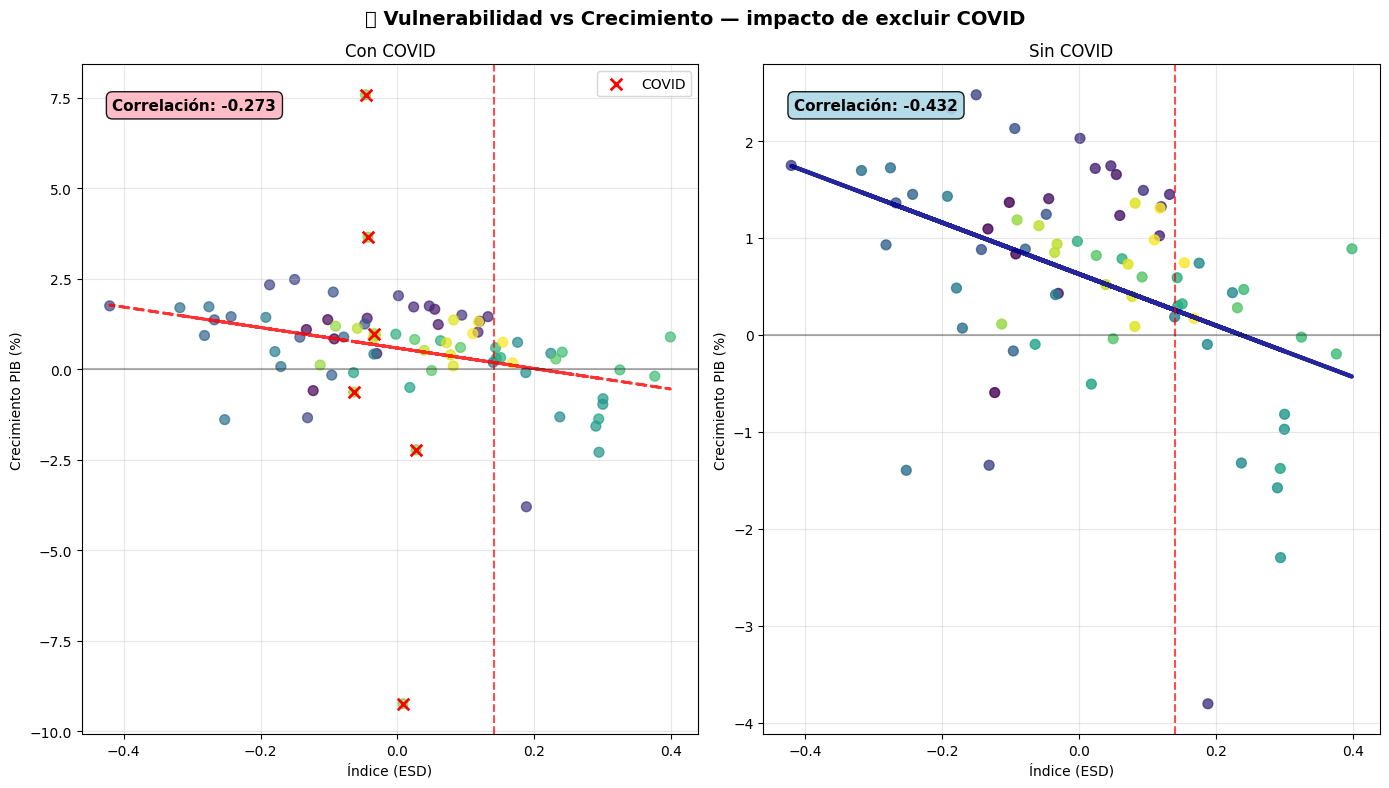

✅ Diagnóstico visual generado correctamente.


In [52]:
# ==============================================================================
# FASE 6 → DIAGNÓSTICO VISUAL (autocontenido para ESD)
#   Requiere que ya existan (de tu FASE 6 ESD):
#     - vuln_df  : DataFrame con columna 'indicator' (índice ESD)
#     - components: DataFrame con columnas ['Desequilibrio','Volatilidad'] (z-scores)
#     - df_aligned, figures_dir, final_model_results
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# ------------------ 1) Puente: Fase 6 -> estructura de visualización ------------------

def create_visualization_structure_from_phase6(vuln_df, components, threshold_percentile=75):
    """
    Adapta (vuln_df, components) a la estructura que consumen las funciones de plotting.
    No usa pesos; es 100% compatible con el enfoque ESD.
    """
    out = pd.DataFrame(index=vuln_df.index)

    # Índice de vulnerabilidad (nombre estándar que esperan los plots)
    if "indicator" in vuln_df.columns:
        idx = vuln_df["indicator"].rename("Vulnerability_Index_Optimized")
    else:
        # fallback si hubiera cambiado el nombre
        col_guess = [c for c in vuln_df.columns if "vulner" in c.lower() or "indic" in c.lower()]
        if not col_guess:
            raise ValueError("No se encontró la columna del indicador en vuln_df.")
        idx = vuln_df[col_guess[0]].rename("Vulnerability_Index_Optimized")

    out["Vulnerability_Index_Optimized"] = idx
    out["Vulnerability_Index"] = idx  # alias de compatibilidad

    # Componentes (z-scores creados en Fase 6)
    out["Desequilibrium_Component"] = components["Desequilibrio"].reindex(out.index)
    out["Volatility_Component"]     = components["Volatilidad"].reindex(out.index)

    # Umbral por percentil histórico
    vals = out["Vulnerability_Index_Optimized"].dropna().values
    thr = np.percentile(vals, threshold_percentile) if len(vals) else np.nan
    out["High_Vulnerability_Episode"] = out["Vulnerability_Index_Optimized"] > thr
    out["Vulnerability_Percentile"]   = out["Vulnerability_Index_Optimized"].rank(pct=True) * 100

    return {
        "vulnerability_data": out,
        "vulnerability_threshold": thr,
        "model_diagnostics": {
            "ect_coefficient": final_model_results.get("ect_coefficient", np.nan),
            "r_squared": final_model_results.get("r_squared", np.nan),
        }
    }

optimized_vulnerability_results = create_visualization_structure_from_phase6(
    vuln_df=vuln_df,
    components=components,
    threshold_percentile=75
)

# ------------------ 2) Plots: overview 4 paneles (versión ESD, sin pesos) --------------

def plot_gdp_vulnerability_analysis_esd(df_aligned, vulnerability_results, figsize=(16, 12), save_fig=False):
    """
    Análisis integral para el índice ESD (sin pesos). Panel 4 apila z-scores de
    Desequilibrio y Volatilidad, y superpone el índice ESD en eje secundario.
    """
    vd = vulnerability_results["vulnerability_data"]
    threshold = vulnerability_results["vulnerability_threshold"]

    # Series base
    vuln_series = vd["Vulnerability_Index_Optimized"]
    gdp_level   = df_aligned['log_gdp_brazil'].dropna()
    gdp_growth  = (df_aligned['log_gdp_brazil'].diff() * 100).dropna()

    # Alineación
    common_idx = vuln_series.index.intersection(gdp_level.index)

    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('📊 PIB vs Vulnerabilidad Externa — Brasil (ESD)',
                 fontsize=16, fontweight='bold', y=0.98)

    # ---- Panel 1: PIB (log) vs Índice ----
    ax1 = axes[0,0]
    ax1.plot(common_idx, gdp_level.loc[common_idx], color='steelblue', linewidth=2.3, label='PIB Real (log)')
    ax1.set_ylabel('PIB Real (log)', color='steelblue'); ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.grid(True, alpha=0.3); ax1.set_title('PIB Real vs Índice de Vulnerabilidad', fontweight='bold', pad=8)

    ax1b = ax1.twinx()
    ax1b.plot(vd.index, vuln_series, color='darkred', linewidth=2, alpha=0.9, label='Índice (ESD)')
    if np.isfinite(threshold):
        ax1b.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, label=f'Umbral p75 ({threshold:.2f})')
    ax1b.set_ylabel('Índice (ESD)', color='darkred'); ax1b.tick_params(axis='y', labelcolor='darkred')

    # Sombrear episodios altos
    if 'High_Vulnerability_Episode' in vd.columns:
        high = vd['High_Vulnerability_Episode']
        for i in range(len(high)-1):
            if bool(high.iloc[i]):
                ax1.axvspan(vd.index[i], vd.index[i+1], color='red', alpha=0.15)

    # Leyenda combinada
    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1+l2, lab1+lab2, loc='upper left', fontsize=9)

    # ---- Panel 2: Crecimiento vs Índice ----
    ax2 = axes[0,1]
    growth_al = gdp_growth.reindex(vd.index)
    ax2.plot(vd.index, growth_al, color='green', linewidth=1.6, alpha=0.8, label='Crecimiento PIB (%)')
    ax2.axhline(0, color='black', alpha=0.3); ax2.grid(True, alpha=0.3)
    ax2.set_title('Crecimiento PIB vs Índice', fontweight='bold', pad=8)
    ax2.set_ylabel('Crec. trimestral (%)', color='green'); ax2.tick_params(axis='y', labelcolor='green')

    ax2b = ax2.twinx()
    ax2b.plot(vd.index, vuln_series, color='darkred', linewidth=2, alpha=0.9, label='Índice (ESD)')
    ax2b.set_ylabel('Índice (ESD)', color='darkred'); ax2b.tick_params(axis='y', labelcolor='darkred')

    # ---- Panel 3: Scatter sin COVID ----
    ax3 = axes[1,0]
    df_sc = pd.DataFrame({'v': vuln_series, 'g': growth_al}).dropna()
    covid_mask = (df_sc.index.year == 2020) | ((df_sc.index.year == 2021) & (df_sc.index.quarter <= 2))
    clean = df_sc.loc[~covid_mask]
    ax3.scatter(clean['v'], clean['g'], c=clean.index.year, cmap='viridis', alpha=0.75, s=45)
    if len(clean) > 5:
        z = np.polyfit(clean['v'], clean['g'], 1); p = np.poly1d(z)
        ax3.plot(clean['v'], p(clean['v']), 'r--', lw=2, alpha=0.8, label='Tendencia (sin COVID)')
        ax3.text(0.05, 0.95, f"Corr (sin COVID): {clean['v'].corr(clean['g']):.3f}",
                 transform=ax3.transAxes, ha='left', va='top',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9))
    ax3.grid(True, alpha=0.3); ax3.set_xlabel('Índice (ESD)'); ax3.set_ylabel('Crec. PIB (%)')
    ax3.set_title('Vulnerabilidad vs Crecimiento (sin COVID)', fontweight='bold')

    # ---- Panel 4: Descomposición (z-scores) + Índice en eje secundario ----
    ax4 = axes[1,1]
    dates = vd.index
    deseq = vd['Desequilibrium_Component']
    volat = vd['Volatility_Component']

    base = np.zeros(len(dates))
    ax4.fill_between(dates, base, base + deseq, alpha=0.6, color='steelblue', label='Desequilibrio (z-score)')
    ax4.fill_between(dates, base + deseq, base + deseq + volat, alpha=0.6, color='orange', label='Volatilidad (z-score)')
    ax4.set_ylabel('Unidades normalizadas (z-score)')
    ax4.grid(True, alpha=0.3); ax4.set_title('Descomposición (z-scores) + Índice', fontweight='bold')

    ax4b = ax4.twinx()
    ax4b.plot(dates, vuln_series, color='darkred', lw=2.4, label='Índice (ESD)')
    ax4b.set_ylabel('Índice (ESD)', color='darkred'); ax4b.tick_params(axis='y', labelcolor='darkred')

    # Leyenda del panel 4 (combinar ambas)
    l1, lab1 = ax4.get_legend_handles_labels()
    l2, lab2 = ax4b.get_legend_handles_labels()
    ax4.legend(l1 + l2, lab1 + lab2, loc='upper left', fontsize=9)

    # Formato fechas
    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        if hasattr(ax, 'xaxis'):
            ax.xaxis.set_major_locator(YearLocator(2))
            ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    plt.tight_layout(); plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.25)

    if save_fig:
        plt.savefig(f"{figures_dir}/vulnerability_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
        print("✅ Figura guardada: vulnerability_analysis.pdf")

    plt.show()

# ------------------ 3) Plot de correlación COVID vs sin COVID --------------------------

def plot_vulnerability_correlation_analysis(df_aligned, vulnerability_results, figsize=(14, 8)):
    """
    Comparativa de correlación Índice–Crecimiento con y sin COVID. Guarda PDF.
    """
    vd = vulnerability_results['vulnerability_data']
    threshold = vulnerability_results['vulnerability_threshold']
    vuln_col = 'Vulnerability_Index_Optimized' if 'Vulnerability_Index_Optimized' in vd.columns else 'Vulnerability_Index'

    gdp_growth = (df_aligned['log_gdp_brazil'].diff() * 100).dropna()
    analysis = pd.DataFrame({
        'vulnerability': vd[vuln_col],
        'gdp_growth': gdp_growth.reindex(vd.index),
        'year': vd.index.year,
        'quarter': vd.index.quarter
    }).dropna()

    covid_mask = (analysis['year'] == 2020) | ((analysis['year'] == 2021) & (analysis['quarter'] <= 2))
    clean = analysis.loc[~covid_mask]
    covid = analysis.loc[covid_mask]

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('🔍 Vulnerabilidad vs Crecimiento — impacto de excluir COVID', fontsize=14, fontweight='bold')

    # Left: con COVID
    ax1 = axes[0]
    ax1.scatter(analysis['vulnerability'], analysis['gdp_growth'], c=analysis['year'], cmap='viridis', alpha=0.7, s=50)
    if len(analysis) > 5:
        z1 = np.polyfit(analysis['vulnerability'], analysis['gdp_growth'], 1); p1 = np.poly1d(z1)
        ax1.plot(analysis['vulnerability'], p1(analysis['vulnerability']), "r--", alpha=0.8, lw=2)
        corr1 = analysis['vulnerability'].corr(analysis['gdp_growth'])
        ax1.text(0.05, 0.95, f'Correlación: {corr1:.3f}', transform=ax1.transAxes,
                 fontsize=11, weight='bold', va='top', bbox=dict(boxstyle="round,pad=0.4", facecolor="lightpink", alpha=0.9))
    if np.isfinite(threshold):
        ax1.axvline(threshold, color='red', ls='--', alpha=0.7)
    ax1.axhline(0, color='black', alpha=0.3)
    if len(covid) > 0:
        ax1.scatter(covid['vulnerability'], covid['gdp_growth'], color='red', marker='x', s=70, lw=2, label='COVID')
        ax1.legend()
    ax1.set_xlabel('Índice (ESD)'); ax1.set_ylabel('Crecimiento PIB (%)'); ax1.grid(True, alpha=0.3)
    ax1.set_title('Con COVID')

    # Right: sin COVID
    ax2 = axes[1]
    if len(clean) > 0:
        ax2.scatter(clean['vulnerability'], clean['gdp_growth'], c=clean['year'], cmap='viridis', alpha=0.8, s=50)
        if len(clean) > 5:
            z2 = np.polyfit(clean['vulnerability'], clean['gdp_growth'], 1); p2 = np.poly1d(z2)
            ax2.plot(clean['vulnerability'], p2(clean['vulnerability']), "darkblue", lw=3, alpha=0.85)
            corr2 = clean['vulnerability'].corr(clean['gdp_growth'])
            ax2.text(0.05, 0.95, f'Correlación: {corr2:.3f}', transform=ax2.transAxes,
                     fontsize=11, weight='bold', va='top',
                     bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.9))
    if np.isfinite(threshold):
        ax2.axvline(threshold, color='red', ls='--', alpha=0.7)
    ax2.axhline(0, color='black', alpha=0.3)
    ax2.set_xlabel('Índice (ESD)'); ax2.set_ylabel('Crecimiento PIB (%)'); ax2.grid(True, alpha=0.3)
    ax2.set_title('Sin COVID')

    plt.tight_layout()
    plt.savefig(f"{figures_dir}/covid_correlation_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
    print("✅ Figura guardada: covid_correlation_analysis.pdf")
    plt.show()

# ------------------ 4) Ejecutar y guardar figuras --------------------------------------

plot_gdp_vulnerability_analysis_esd(
    df_aligned,
    optimized_vulnerability_results,
    save_fig=True
)

covid_analysis = plot_vulnerability_correlation_analysis(
    df_aligned,
    optimized_vulnerability_results
)

print("✅ Diagnóstico visual generado correctamente.")


## Fase 6 · Atribución dinámica de la incertidumbre del índice ESD

Esta sección analiza **qué factores generan mayor incertidumbre en la vulnerabilidad macroeconómica**.  
El objetivo no es solo identificar los niveles de desequilibrio o riesgo, sino **entender en cada momento qué canal (estructural o financiero) domina la dinámica del índice ESD**.

#### 1. Variaciones del desequilibrio estructural (Δμₜ)
El primer gráfico descompone la **variación trimestral del desequilibrio (μₜ)** en sus fuentes:
- Cada color representa la contribución de una variable de cointegración (por ejemplo, términos de intercambio, tasas de EE. UU., constante del equilibrio).
- La línea negra indica la variación total Δμₜ.
- Picos positivos o negativos muestran qué componente está **desestabilizando o reequilibrando** la economía en ese trimestre.

Este gráfico permite distinguir entre periodos de **ajuste estructural suave** (μ estable) y fases donde una variable concreta rompe el equilibrio de largo plazo.

#### 2. Contribución de los shocks a la volatilidad (σₜ²)
El segundo gráfico muestra cómo evoluciona la composición del **riesgo de corto plazo**:
- Cada línea representa el peso de un tipo de shock (comercial, financiero, riesgo global, demanda externa) en la varianza total σₜ².
- Los valores son shares porcentuales en una media móvil de cuatro trimestres.

Así puede verse si el riesgo externo proviene principalmente de:
- **Factores financieros** (spreads, tasas de EE. UU.),
- **Choques reales** (términos de intercambio),
- o **perturbaciones de demanda global** (producción del G7).

#### 3. Dominancia relativa de incertidumbre (|μₜ| vs. σₜ)
El tercer gráfico combina ambas dimensiones:
- La línea azul representa la magnitud normalizada del desequilibrio estructural |μₜ|.
- La línea naranja discontinua representa el riesgo externo σₜ.
- Las áreas sombreadas indican qué canal domina:
  - Azul → vulnerabilidad **estructural** (predomina el desequilibrio interno),
  - Naranja → vulnerabilidad **financiera** (predomina el riesgo global).

Este diagnóstico permite responder a la pregunta clave:
> “¿La vulnerabilidad de la economía brasileña proviene más de desequilibrios internos o de condiciones externas?”

En conjunto, los tres gráficos proporcionan una **lectura dinámica y atribuida del riesgo**, mostrando cómo cambian las fuentes de vulnerabilidad en el tiempo.


In [ ]:
# ==============================================================================
# FASE 6 · ATRIBUCIÓN DEL ÍNDICE (μ/σ) A VARIABLES Y SHOCKS
# Requiere: df_aligned, final_model_results, vuln_df, components, g, shock_cols, win
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# ---------------------------------------------------------------------------
# A) DESEQUILIBRIO μₜ: descomposición por variables estructurales y lags del ECT
# ---------------------------------------------------------------------------

def mu_decomposition_by_variable(df, final_model_results, level_vars=None, ect_name='ECT'):
    """
    Descompone el desequilibrio μₜ en:
      - μ_total: suma ponderada de los ECT rezagados (α_L * ECT_{t-L})
      - μ_by_var: contribución de cada variable de cointegración y constante
      - μ_by_lag: contribución de cada lag del ECT

    μₜ mide el componente estructural del desequilibrio (corrección hacia equilibrio).
    """
    ect = final_model_results['ect'].reindex(df.index)
    params = final_model_results['model'].params
    beta = final_model_results['cointegration_model'].params

    # Extrae los coeficientes α_L (velocidades de ajuste)
    alphas = {}
    for name, val in params.items():
        if ect_name.lower() in name.lower():
            import re
            m = re.search(r'(?:_?L|lag)\s*(\d+)', name, flags=re.IGNORECASE)
            L = int(m.group(1)) if m else 1
            alphas[L] = float(val)
    if not alphas:
        raise ValueError("No se encontraron coeficientes α_L del ECT en el modelo.")

    # Variables de cointegración
    if level_vars is None:
        level_vars = [v for v in beta.index if v.lower() not in ('const', 'intercept')]

    # μ total: suma α_L * ECT_{t-L}
    mu_total = pd.Series(0.0, index=df.index, name='μ_total')
    for L, aL in alphas.items():
        mu_total += aL * ect.shift(L)

    # Contribución por variable (lineal): α_L * β_v * z_{v,t-L}
    mu_by_var = pd.DataFrame(0.0, index=df.index, columns=level_vars + ['const'])
    b0 = float(beta.get('const', beta.get('Intercept', 0.0)))
    for L, aL in alphas.items():
        if b0 != 0.0:
            mu_by_var['const'] += aL * b0
        for v in level_vars:
            mu_by_var[v] += aL * float(beta[v]) * df[v].shift(L)

    # Contribución por lag del ECT
    mu_by_lag = pd.DataFrame({f'ECT_L{L}': aL * ect.shift(L) for L, aL in alphas.items()}, index=df.index)

    return mu_total, mu_by_var, mu_by_lag

mu_total, mu_by_var, mu_by_lag = mu_decomposition_by_variable(df_aligned, final_model_results)

# ---------------------------------------------------------------------------
# B) RIESGO σₜ²: contribución de cada shock a la volatilidad (tipo Shapley)
# ---------------------------------------------------------------------------

def sigma_and_var_contribs(df, shock_cols, g, window=40, min_periods=None):
    """
    Calcula σₜ y sus contribuciones por shock.
    σₜ² = g' Σ_t g  → contribución_i = g_i * (Σ_t g)_i
    Devuelve:
      - sigma: Serie σₜ
      - var_contribs: DataFrame con contribuciones absolutas
      - var_shares: shares relativos c_i,t / σₜ²
    """
    if min_periods is None:
        min_periods = max(20, len(shock_cols)*3)

    sigma = pd.Series(np.nan, index=df.index, name='σ_shock')
    var_contribs = pd.DataFrame(np.nan, index=df.index, columns=shock_cols)

    for t in range(len(df)):
        start = max(0, t-window+1)
        sample = df.iloc[start:t+1][shock_cols].dropna()
        if len(sample) >= min_periods:
            S = sample.cov().values
            gvec = np.asarray(g, dtype=float).reshape(-1)
            sigma2 = float(gvec @ S @ gvec)
            sigma.iloc[t] = np.sqrt(max(0.0, sigma2))
            var_contribs.iloc[t] = gvec * (S @ gvec)  # contribuciones absolutas
    var_shares = var_contribs.div((sigma**2), axis=0)
    return sigma, var_contribs, var_shares

sigma_chk, var_contribs, var_shares = sigma_and_var_contribs(df=df_aligned, shock_cols=shock_cols, g=g, window=win)

'''
# ---------------------------------------------------------------------------
# C) Diagnósticos numéricos: medias y últimos valores
# ---------------------------------------------------------------------------

mu_var_stats = mu_by_var.agg(['mean', 'quantile', 'last']).T
mu_var_stats['quantile'] = mu_by_var.quantile(0.95)
mu_var_stats['last'] = mu_by_var.iloc[-1]
mu_var_stats = mu_var_stats.sort_values('mean', ascending=False)

var_shares_stats = pd.DataFrame({
    'mean_share': var_shares.mean(),
    'last_share': var_shares.iloc[-1]
}).sort_values('mean_share', ascending=False)

print("=== Atribución de μₜ por variables de cointegración ===")
print(mu_var_stats.round(4).to_string())
print("\n=== Atribución de σₜ² por shocks ===")
print((100 * var_shares_stats).round(1).to_string())

# ---------------------------------------------------------------------------
# D) Visualización integrada: qué domina la incertidumbre
# ---------------------------------------------------------------------------

# --- (1) μₜ por variable (stacked area)
common = mu_by_var.index.intersection(mu_total.index)
plt.figure(figsize=(12,4))
base = np.zeros(len(common))
for v in mu_by_var.columns:
    vals = mu_by_var.loc[common, v].values
    plt.fill_between(common, base, base + vals, alpha=0.6, label=v)
    base += vals
plt.plot(common, mu_total.loc[common], lw=2.2, color='black', label='μ total')
plt.title('Atribución del desequilibrio estructural (μₜ)')
plt.xlabel('Fecha'); plt.ylabel('Contribución')
plt.legend(loc='upper left', ncol=3, fontsize=9); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/mu_decomposition.pdf', dpi=300, bbox_inches='tight'); plt.show()

# --- (2) σₜ² por shock (shares %)
shares_smooth = var_shares.rolling(4, min_periods=1).mean() * 100
plt.figure(figsize=(12,4))
for sc in shock_cols:
    plt.plot(shares_smooth.index, shares_smooth[sc], lw=2, label=sc)
plt.title('Contribución de cada shock a la volatilidad total σₜ²')
plt.xlabel('Fecha'); plt.ylabel('% de σₜ²')
plt.legend(loc='upper left'); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/sigma_shares_by_shock.pdf', dpi=300, bbox_inches='tight'); plt.show()

# --- (3) Composición de la incertidumbre total: |μₜ| vs σₜ
# Idea: visualizar quién "domina" la vulnerabilidad (desequilibrio o riesgo)
plt.figure(figsize=(10,5))
plt.plot(df_aligned.index, mu_total.abs()/mu_total.abs().max(), lw=2, label='Desequilibrio |μₜ| (norm.)')
plt.plot(df_aligned.index, sigma_chk/sigma_chk.max(), lw=2, label='Riesgo σₜ (norm.)', linestyle='--')
plt.title('Peso relativo de desequilibrio estructural y riesgo externo en la vulnerabilidad')
plt.xlabel('Fecha'); plt.ylabel('Escala normalizada')
plt.legend(); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/uncertainty_composition.pdf', dpi=300, bbox_inches='tight'); plt.show()

'''


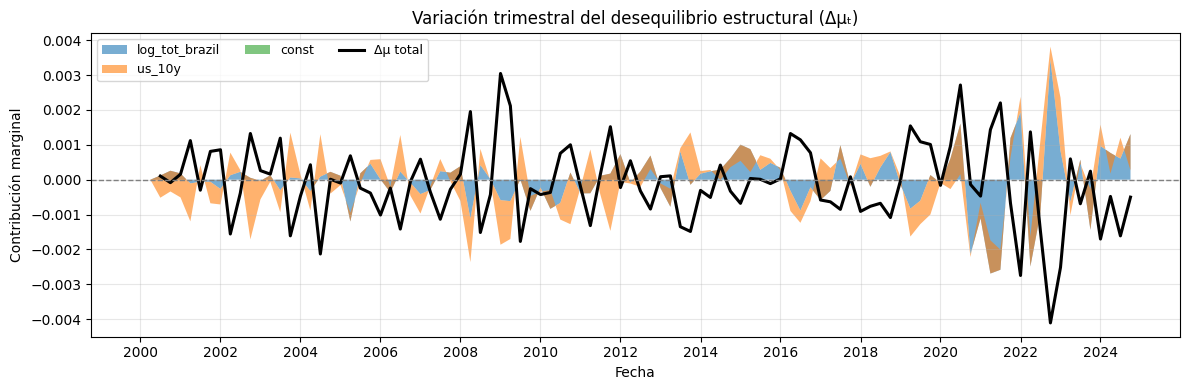

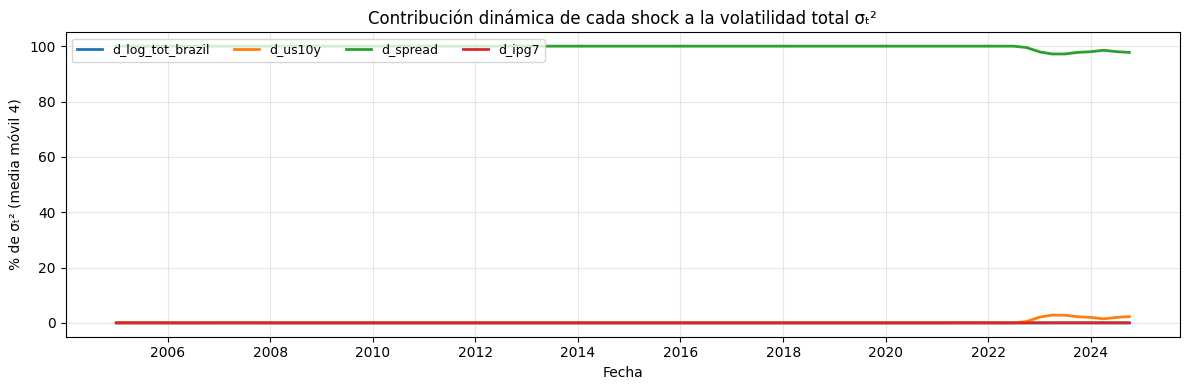

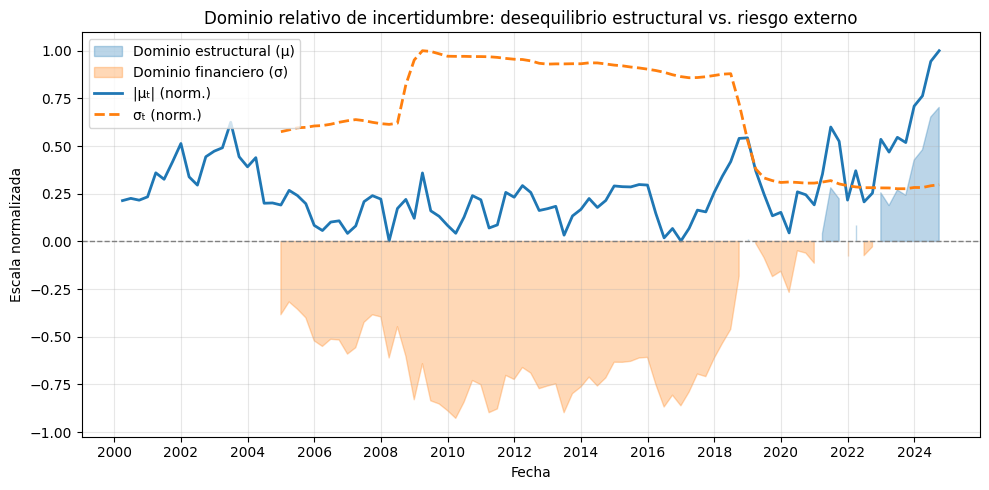

In [55]:
# ==============================================================================
# FASE 6bis · ATRIBUCIÓN DINÁMICA DEL ÍNDICE — Quién aporta incertidumbre
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# --- 1. Cambios trimestrales de μₜ por variable (dinámica del desequilibrio)
mu_by_var_diff = mu_by_var.diff()  # variación marginal
mu_total_diff = mu_total.diff()

plt.figure(figsize=(12,4))
base = np.zeros(len(mu_by_var_diff))
for v in mu_by_var_diff.columns:
    vals = mu_by_var_diff[v].fillna(0).values
    plt.fill_between(mu_by_var_diff.index, base, base + vals, alpha=0.6, label=v)
    base += vals
plt.plot(mu_by_var_diff.index, mu_total_diff, lw=2.2, color='black', label='Δμ total')
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.title('Variación trimestral del desequilibrio estructural (Δμₜ)')
plt.xlabel('Fecha'); plt.ylabel('Contribución marginal')
plt.legend(loc='upper left', ncol=3, fontsize=9)
plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/mu_dynamic_contribs.pdf', dpi=300, bbox_inches='tight'); plt.show()

# --- 2. Riesgo σₜ²: shares dinámicos normalizados
shares_dyn = var_shares.rolling(4, min_periods=1).mean() * 100
shares_dyn = shares_dyn.clip(lower=0, upper=100)
plt.figure(figsize=(12,4))
for sc in shock_cols:
    plt.plot(shares_dyn.index, shares_dyn[sc], lw=2, label=sc)
plt.title('Contribución dinámica de cada shock a la volatilidad total σₜ²')
plt.xlabel('Fecha'); plt.ylabel('% de σₜ² (media móvil 4)')
plt.legend(loc='upper left', ncol=4, fontsize=9); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/sigma_dynamic_shares.pdf', dpi=300, bbox_inches='tight'); plt.show()

# --- 3. Índice de "incertidumbre relativa": qué canal domina (μ vs σ)
# Normaliza ambos componentes
mu_norm = mu_total.abs() / mu_total.abs().max()
sigma_norm = sigma_chk / sigma_chk.max()
dominance = mu_norm - sigma_norm  # >0: domina desequilibrio; <0: domina riesgo

plt.figure(figsize=(10,5))
plt.fill_between(dominance.index, 0, dominance, where=dominance>0, color='tab:blue', alpha=0.3, label='Dominio estructural (μ)')
plt.fill_between(dominance.index, 0, dominance, where=dominance<0, color='tab:orange', alpha=0.3, label='Dominio financiero (σ)')
plt.plot(mu_norm.index, mu_norm, lw=2, color='tab:blue', label='|μₜ| (norm.)')
plt.plot(sigma_norm.index, sigma_norm, lw=2, color='tab:orange', linestyle='--', label='σₜ (norm.)')
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.title('Dominio relativo de incertidumbre: desequilibrio estructural vs. riesgo externo')
plt.xlabel('Fecha'); plt.ylabel('Escala normalizada')
plt.legend(loc='upper left'); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/uncertainty_dominance.pdf', dpi=300, bbox_inches='tight'); plt.show()


#### Dynamic Attribution of Vulnerability Components

The dynamic decomposition of the ESD indicator provides a time-varying view of the relative contribution of structural and financial factors to Brazil’s macroeconomic vulnerability.

The structural component (μₜ) captures the equilibrium correction process derived from the error-correction model.  
Its quarterly variations (Δμₜ) reveal which long-term relationships — such as terms of trade, U.S. interest rates or the constant of the cointegrating vector — drive deviations from equilibrium in each period. Positive or negative peaks in Δμₜ indicate moments of structural destabilization or adjustment, respectively.

The risk component (σₜ²) measures external volatility derived from the covariance structure of shocks.  
Its decomposition by source (trade, financial, or global-demand shocks) shows which channels dominate the short-term uncertainty at each point in time. The dynamic shares of σₜ² highlight whether vulnerability arises from financial tightening, commodity shocks or external demand conditions.

Finally, the relative dominance between |μₜ| and σₜ identifies whether vulnerability is primarily **structural** or **financial**.  
Periods where |μₜ| exceeds σₜ denote vulnerability driven by internal disequilibria, whereas σₜ > |μₜ| reflects exposure to external risk and global volatility.

Together, these decompositions provide a granular understanding of the evolving balance between internal adjustment pressures and external shocks, clarifying which mechanisms contribute most to Brazil’s macro-financial fragility over time.
